In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
!whoami
!date

zmbc
Thu May 14 15:14:36 PDT 2026


# V&V neonatal mortality in an interactive simulation

General approach:
* Check quantities subject to stochastic uncertainty both visually and with a statistical test
* Single draw, location, and scenario (baseline)
* Only test relative to artifact, because GBD shared functions can't be directly used in the sim environment -- **this notebook will not find issues in artifact creation**

In [3]:
%pip list | grep vivarium

vivarium                                 4.0.2
vivarium_build_utils                     2.3.8
vivarium_cluster_tools                   3.0.0
vivarium_dependencies                    1.0.7
vivarium_gates_mncnh                     33.1.dev3+gfb9a80fb8 /mnt/share/homes/zmbc/src/vivarium_gates_mncnh
vivarium_public_health                   5.0.1
vivarium_testing_utils                   0.5.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip freeze | grep vivarium

vivarium==4.0.2
vivarium_build_utils==2.3.8
vivarium_cluster_tools==3.0.0
vivarium_dependencies==1.0.7
-e git+https://github.com/ihmeuw/vivarium_gates_mncnh.git@fb9a80fb8aa5e421fabff4e89d1278c8c89c18cf#egg=vivarium_gates_mncnh
vivarium_public_health==5.0.1
vivarium_testing_utils==0.5.1
Note: you may need to restart the kernel to use updated packages.


In [5]:
! cat /mnt/share/homes/zmbc/src/vivarium_gates_mncnh/.git/HEAD

ref: refs/heads/neonatal_mortality_vv


In [6]:
draw_num = 60

In [7]:
from pathlib import Path

In [ ]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

main_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
)
del main_sim_model_specification.configuration.observers
main_sim_model_specification.configuration.input_data.input_draw_number = draw_num
main_sim_model_specification.configuration.population.population_size = 10_000_000

In [ ]:
paf_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'data/lbwsg_paf/code/lbwsg_paf.yaml'
)
# Don't delete observers since we use these to get the PAFs
paf_sim_model_specification.configuration.input_data.input_draw_number = draw_num
paf_sim_model_specification.configuration.population.population_size = (
    400**2 # 400x400 grid on gestational age and birth weight...
    * 58 # ... in each LBWSG category
    * 2 # ... for each sex
)

In [10]:
location = "Ethiopia"

In [11]:
orig_location = Path(main_sim_model_specification.configuration.input_data.artifact_path).stem
assert orig_location == Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem
orig_location

'ethiopia'

In [12]:
main_sim_model_specification.configuration.input_data.artifact_path = main_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(main_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()
paf_sim_model_specification.configuration.input_data.artifact_path = paf_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()

In [13]:
art = Artifact(main_sim_model_specification.configuration.input_data.artifact_path)

## Create simulations

In [14]:
%%time

main_sim = InteractiveContext(main_sim_model_specification)

2026-05-14 15:14:42.071 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model33.0/ethiopia.hdf.
2026-05-14 15:14:42.072 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].
2026-05-14 15:14:42.073 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.
2026-05-14 15:14:42.072 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].
2026-05-14 15:14:42.073 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.
2026-05-14 15:15:04.449 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2026-05-14 15:15:04.451 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['

In [15]:
main_sim_components = main_sim.list_components()
list(main_sim_components.keys())

['risk_factor.hemoglobin',
 'anemia_intervention_propensity',
 'ageless_population.population.scaling_factor',
 'pregnancy',
 'new_children',
 'results_stratifier',
 'anc_attendance',
 'ultrasound',
 'maternal_disorder.maternal_obstructed_labor_and_uterine_rupture',
 'maternal_disorder.maternal_hemorrhage',
 'maternal_disorder.maternal_sepsis_and_other_maternal_infections',
 'residual_maternal_disorders',
 'abortion_miscarriage_ectopic_pregnancy',
 'maternal_disorders_burden',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_spec

In [16]:
%%time

paf_sim = InteractiveContext(paf_sim_model_specification)

2026-05-14 15:15:07.397 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model28.1/ethiopia.hdf.
2026-05-14 15:15:07.398 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].
2026-05-14 15:15:07.399 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.


2026-05-14 15:15:10.521 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'exposure' during setup.
2026-05-14 15:15:10.523 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.
2026-05-14 15:15:10.524 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'exposure_standard_deviation' during setup.
2026-05-14 15:15:10.523 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.
2026-05-14 15:15:10.524 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_sho

In [17]:
paf_sim_components = paf_sim.list_components()
list(paf_sim_components.keys())

['paf_results_stratifier',
 'evenly_distributed_population',
 'lbwsg_mortality',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk',
 'preterm_prevalence_observer']

## ENN mortality

### Step main sim to ENN mortality

In [18]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'first_trimester_anc'

In [19]:
%%time

while get_event_name() != 'early_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-05-14 15:15:17.010 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-01 00:00:00


later_pregnancy_screening
2026-05-14 15:15:29.267 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-02 00:00:00
later_pregnancy_intervention
2026-05-14 15:15:30.488 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-03 00:00:00
later_pregnancy_visit_timing
2026-05-14 15:15:32.278 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-04 00:00:00
ultrasound
2026-05-14 15:15:44.370 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-05 00:00:00
delivery_facility
2026-05-14 15:15:58.709 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-06 00:00:00
azithromycin_access
2026-05-14 15:15:59.519 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-07 00:00:00
misoprostol_access
2026-05-14 15:16:00.324 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-08 00:00:00
cpap_access
2026-05-14 15:16:01.108 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-09 00:00:00
acs_

In [20]:
assert get_event_name() == 'early_neonatal_mortality'

### Check that PAF sim is in ENN

In [21]:
from vivarium_gates_mncnh.constants.data_values import LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END

assert (paf_sim.get_population(["child_age"]).child_age < LATE_NEONATAL_AGE_START).all()

### Transfer PAFs and preterm prevalence to main sim

In [22]:
from vivarium.framework.event import Event

In [23]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [24]:
def process_pafs(pafs):
    pafs = pafs.rename(columns={"child_sex": "sex_of_child"})
    pafs["child_age_start"] = pafs["child_age_group"].map({
        "early_neonatal": 0,
        "late_neonatal": LATE_NEONATAL_AGE_START,
    })
    pafs["child_age_end"] = pafs["child_age_group"].map({
        "early_neonatal": LATE_NEONATAL_AGE_START,
        "late_neonatal": LATE_NEONATAL_AGE_END,
    })
    pafs["year_start"] = 2021
    pafs["year_end"] = 2022

    return pafs.drop(columns=["child_age_group"])

In [25]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823836,0.000000,0.019178,2021,2022
1,Male,0.847793,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [26]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957251,0.000000,0.019178,2021,2022
1,Male,0.951475,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [27]:
import vivarium

def update_lookup_table(lookup_table, new_data):
    # NOTE: When we get to Vivarium 4.1 we can just call lookup_table.set_data(new_data)
    lookup_table.data = new_data
    # https://github.com/ihmeuw/vivarium/blob/c4d88f7c76df9650f426c43fd44131d5bb272709/src/vivarium/framework/lookup/table.py#L93-L115
    parameter_columns_with_edges: list[tuple[str, str, str]] = [
        (p, f"{p}_start", f"{p}_end") for p in lookup_table.parameter_columns
    ]

    lookup_table.interpolation = vivarium.framework.lookup.table.Interpolation(
        lookup_table.data,
        lookup_table.key_columns,
        parameter_columns_with_edges,
        lookup_table.value_columns,
        order=lookup_table._manager.interpolation_order,
        extrapolate=lookup_table._manager.extrapolate,
        validate=lookup_table._manager.validate_interpolation,
    )

In [28]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [29]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs)

In [30]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [31]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs)

### Check all-cause mortality risk

In [32]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [33]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [34]:
def get_acmrisk_targets(age_group_start, age_group_end):
    return (
        art.load('cause.all_causes.all_cause_mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.age_start == age_group_start) & (df.age_end == age_group_end)])
        .drop(columns=['age_start', 'age_end', 'year_start', 'year_end'])
        .set_index('sex')
        [f'draw_{draw_num}']
    )

In [35]:
enn_acmrisk_targets = get_acmrisk_targets(0, LATE_NEONATAL_AGE_START)
enn_acmrisk_targets

sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

In [36]:
from vivarium_testing_utils.fuzzy_checker import FuzzyChecker
import matplotlib.pyplot as plt

fuzzy_checker = FuzzyChecker()
any_failures = False

def fuzzy_check(observed_values, targets, name, acceptable_deviation=None):
    global any_failures
    print('Targets')
    display(targets)

    observed_value_summaries = observed_values.groupby(pop.sex_of_child).describe()

    print('Summaries of observed values')
    display(observed_value_summaries)

    # if acceptable_deviation is None:
    #     target_lambda = lambda x: x
    # else:
    #     target_lambda = lambda x: (x * (1 - acceptable_deviation), x * (1 + acceptable_deviation))

    # for sex in ['Female', 'Male']:
    #     try:
    #         fuzzy_checker.fuzzy_assert_mean(
    #             observed_values=observed_values[pop.sex_of_child == sex],
    #             target_mean=target_lambda(targets.loc[sex]),
    #             name=f'{name} by sex',
    #         )
    #     except AssertionError as e:
    #         print(e)
    #         any_failures = True

    # try:
    #     overall_target = (pop.loc[alive_idx].groupby('sex_of_child').size() * targets).sum() / len(alive_idx)
    #     fuzzy_checker.fuzzy_assert_mean(
    #         observed_values=observed_values,
    #         target_mean=target_lambda(overall_target),
    #         name=name,
    #     )
    # except AssertionError as e:
    #     print(e)
    #     any_failures = True

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']),
        fmt="o",
    )
    max_val = max(targets.loc[observed_value_summaries.index].max(), observed_value_summaries['mean'].max())
    min_val = min(targets.loc[observed_value_summaries.index].min(), observed_value_summaries['mean'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    plt.title(f'{name} by sex')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value')
    plt.show()

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'] / targets.loc[observed_value_summaries.index],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']) / targets.loc[observed_value_summaries.index],
        fmt="o",
    )
    plt.plot([min_val, max_val], [1, 1], 'k--')
    plt.title(f'{name} by sex relative error')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value / artifact value')
    plt.show()

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.014373,0.044468,0.002560,0.002560,0.003080,0.006011,0.815212
Male,28005.0,0.025302,0.066350,0.003935,0.003958,0.005325,0.012629,0.879632


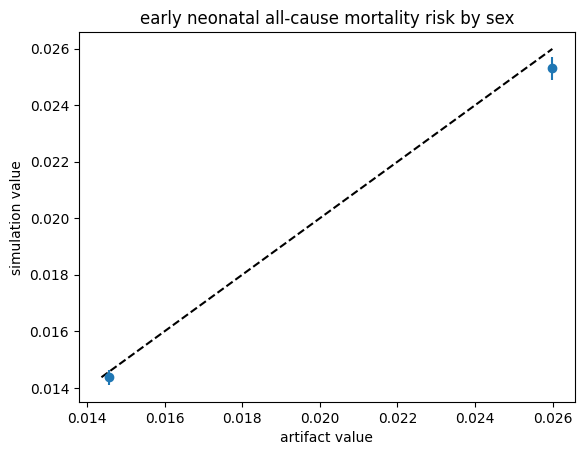

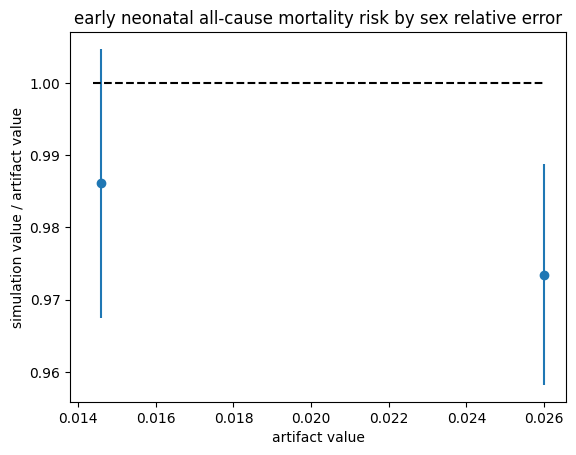

In [37]:
fuzzy_check(mortality_risk, enn_acmrisk_targets, "early neonatal all-cause mortality risk")

#### Check individual steps in calculation of all-cause mortality risk

In [38]:
def step_by_step_check_acmrisk(age_group_start, age_group_end):
    acmrisk_targets = get_acmrisk_targets(age_group_start, age_group_end)
    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial mortality risk')
    initial_all_cause_mortality_risk = main_sim_components['neonatal_mortality'].all_cause_mortality_risk(alive_idx)
    # Does not vary except by sex
    assert (initial_all_cause_mortality_risk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean(), acmrisk_targets, rtol=0, atol=1e-14)
    display(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean())

    # Next (conceptually) is applying LBWSG PAF and RR
    lbwsg_paf = main_sim_components['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk'].paf_table(alive_idx)
    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    lbwsg_rr = pop.loc[alive_idx][f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_all_causes_relative_risk']

    acmrisk_after_lbwsg = initial_all_cause_mortality_risk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(acmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(acmrisk_after_lbwsg, acmrisk_targets, "ACMRisk after LBWSG")

    # Check that we've exactly replicated everything up to mutators
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()["death_in_age_group_probability"]
    assert np.allclose(acmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in CSMRisk-based modifications
    print('Mutators:')
    display(pipeline.mutators)

    working_acmrisk = acmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator}')
        working_acmrisk = mutator(alive_idx, working_acmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = 0.01 if age_group_name == 'late_neonatal' else None
        fuzzy_check(working_acmrisk, acmrisk_targets, "ACMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_acmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

Initial mortality risk


sex_of_child
Female    0.014576
Male      0.025991
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.015146,0.047226,0.002568,0.002568,0.003091,0.006153,0.787756
Male,28005.0,0.027199,0.070271,0.003956,0.003979,0.005390,0.013184,0.841143


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.015146,0.047226,0.002568,0.002568,0.003091,0.006153,0.787756
Male,28005.0,0.027199,0.070271,0.003956,0.003979,0.005390,0.013184,0.841143


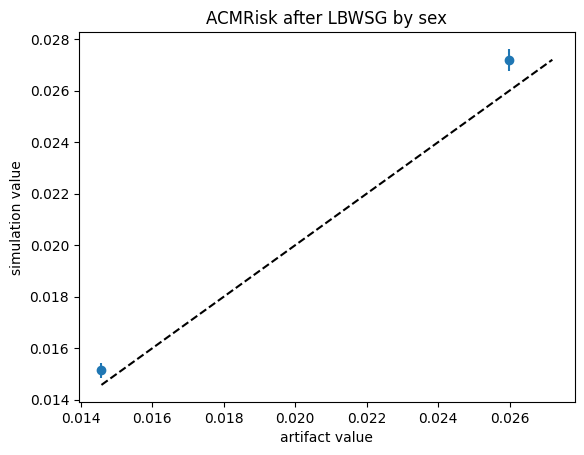

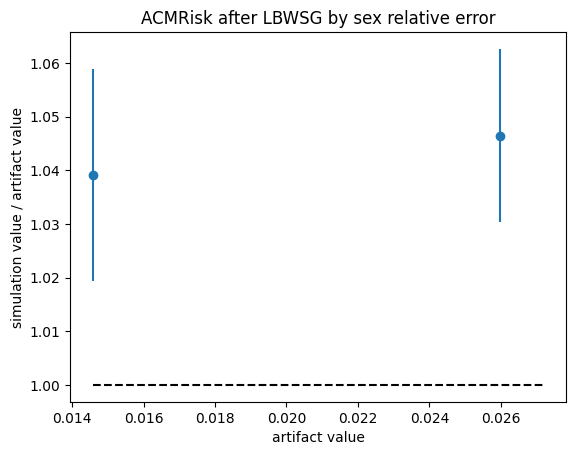

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af910a610>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.014462,0.044760,0.002568,0.002568,0.003090,0.006038,0.817651
Male,28005.0,0.025586,0.067011,0.003956,0.003979,0.005354,0.012762,0.884124


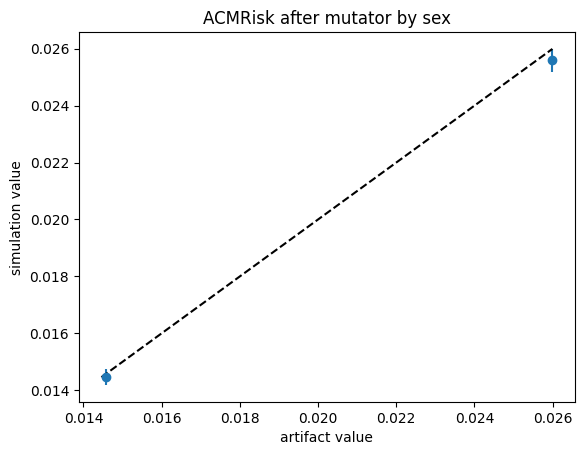

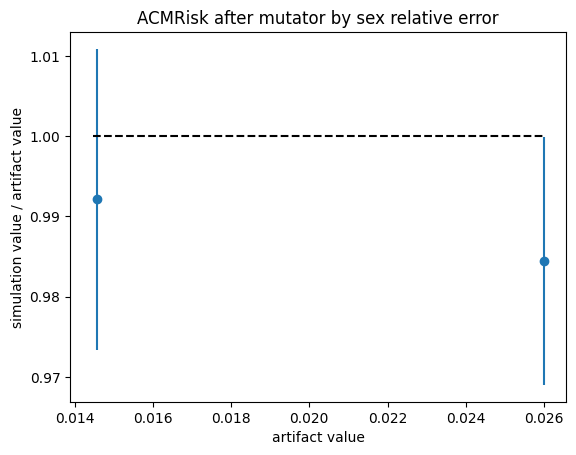

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af89f7f10>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.014462,0.044760,0.002568,0.002568,0.003090,0.006038,0.817651
Male,28005.0,0.025586,0.067011,0.003956,0.003979,0.005354,0.012762,0.884124


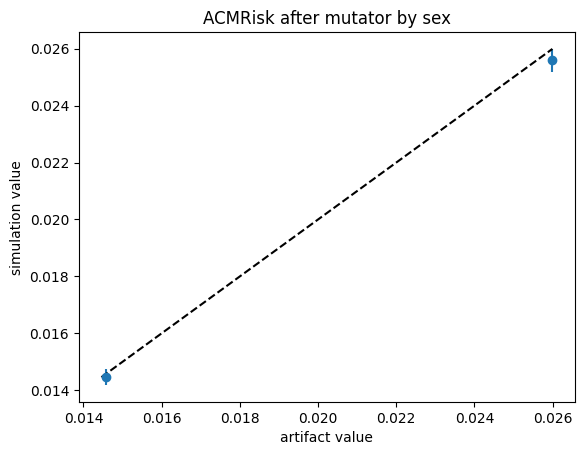

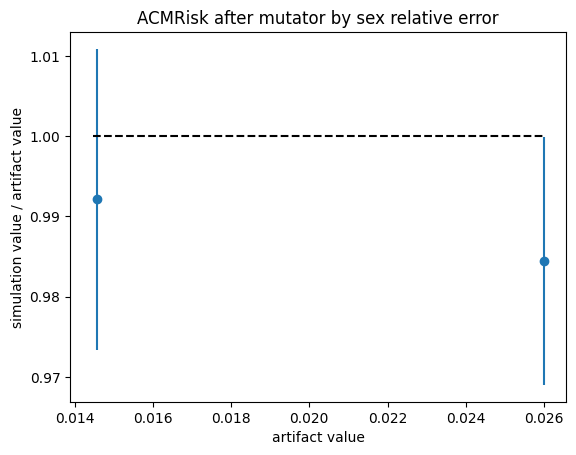

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af89ef950>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.014373,0.044468,0.002560,0.002560,0.003080,0.006011,0.815212
Male,28005.0,0.025302,0.066350,0.003935,0.003958,0.005325,0.012629,0.879632


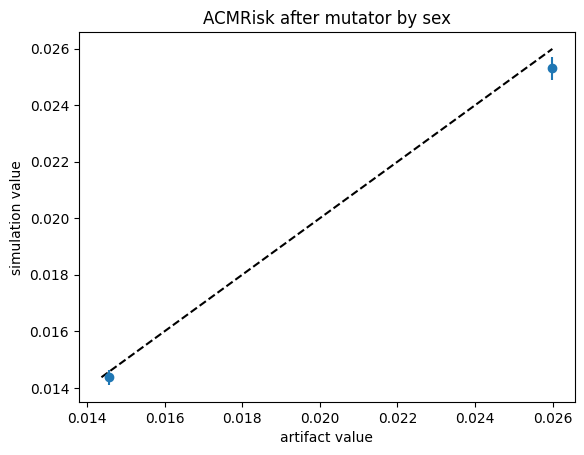

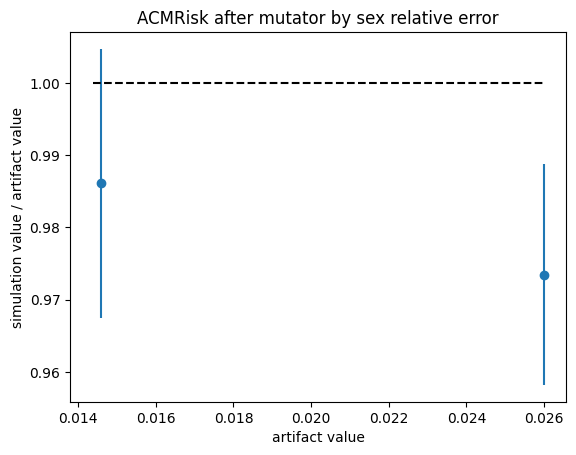

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af8a48810>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.014373,0.044468,0.002560,0.002560,0.003080,0.006011,0.815212
Male,28005.0,0.025302,0.066350,0.003935,0.003958,0.005325,0.012629,0.879632


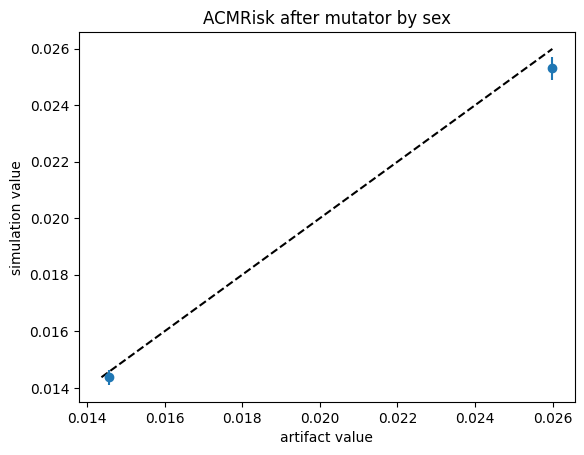

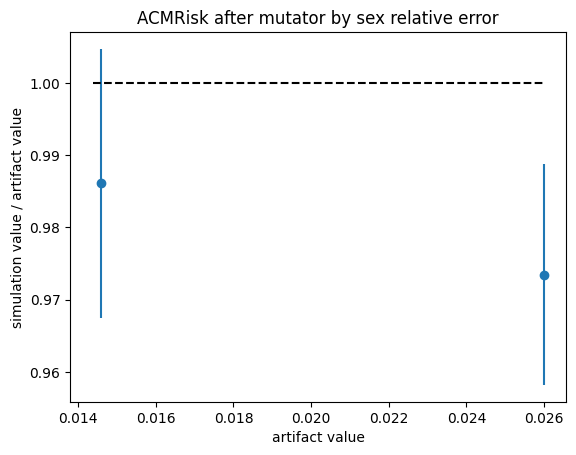

In [39]:
step_by_step_check_acmrisk(0, LATE_NEONATAL_AGE_START)

### Check cause-specific mortality risks

In [40]:
def get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end):
    return (
        art.load(f'cause.{artifact_cause_name}.mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.child_age_start == age_group_start) & (df.child_age_end == age_group_end)])
        .drop(columns=['child_age_start', 'child_age_end', 'year_start', 'year_end'])
        .set_index('sex_of_child')
        [f'draw_{draw_num}']
    )

In [41]:
[c for c in main_sim.get_attribute_names() if 'enceph' in c]

['low_birth_weight_and_short_gestation_on_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.relative_risk',
 'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk',
 'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk.paf',
 'effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk',
 'effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk',
 'lbwsg_paf_on_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk.paf',
 'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr']

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.004285,0.013360,0.000726,0.000726,0.000875,0.001741,0.222860
Male,28005.0,0.009655,0.024945,0.001404,0.001412,0.001913,0.004680,0.298588


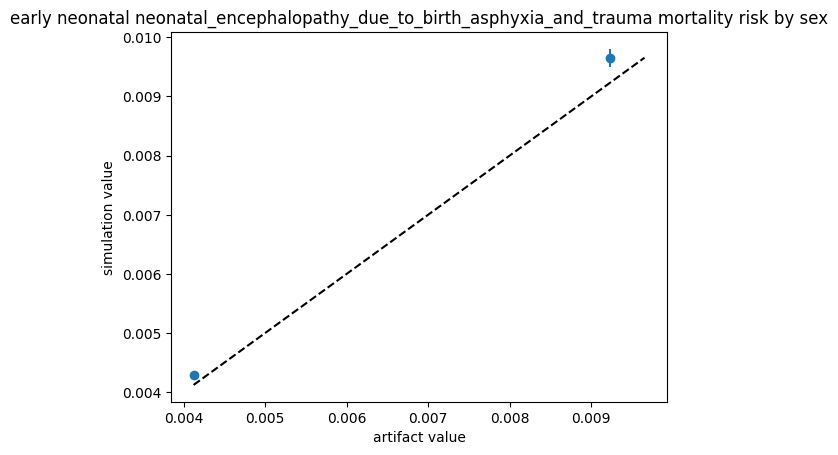

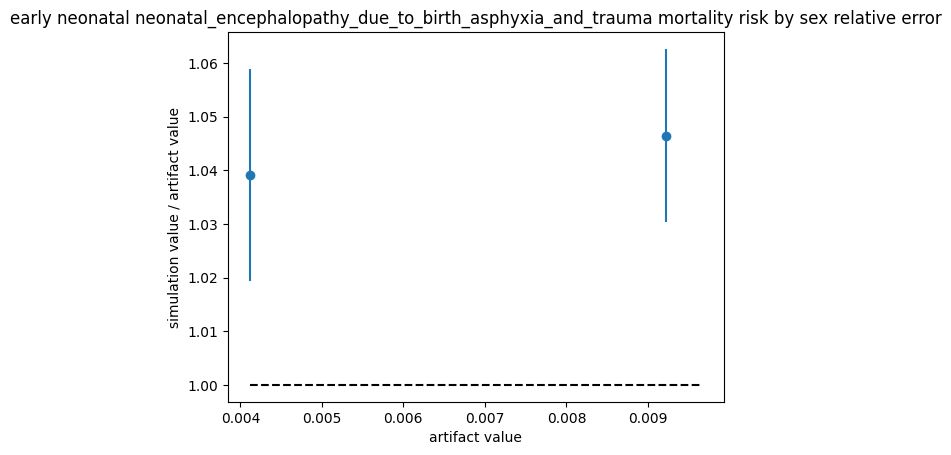

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000807,0.002478,0.000144,0.000144,0.000173,0.000338,0.044107
Male,28005.0,0.002487,0.006433,0.000382,0.000384,0.000518,0.001241,0.081226


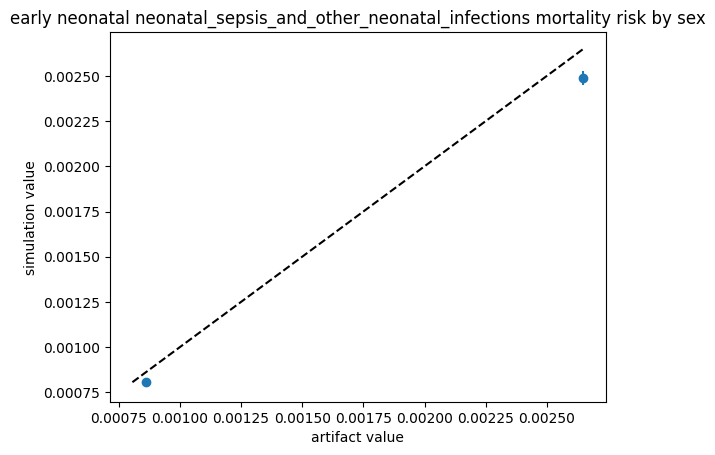

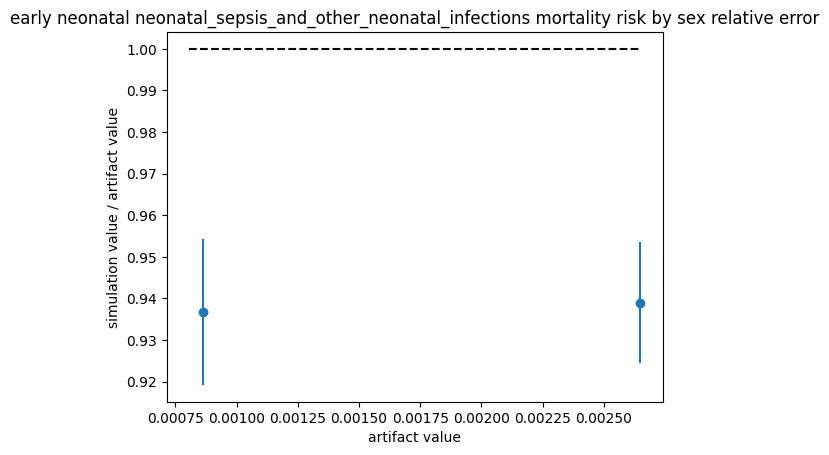

neonatal_preterm_birth
Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002514,0.014477,0.0,0.0,0.0,0.0,0.332777
Male,28005.0,0.005823,0.025763,0.0,0.0,0.0,0.0,0.429215


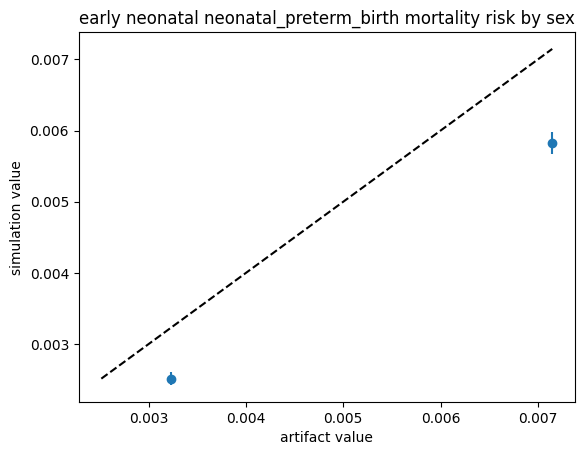

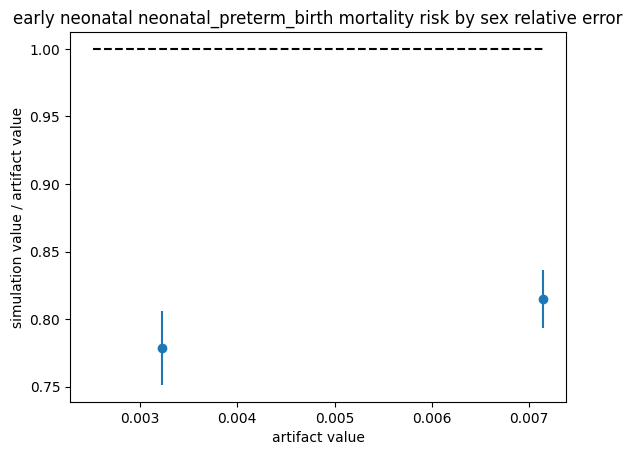

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002034,0.012183,0.0,0.0,0.0,0.0,0.287345
Male,28005.0,0.004708,0.021788,0.0,0.0,0.0,0.0,0.371280


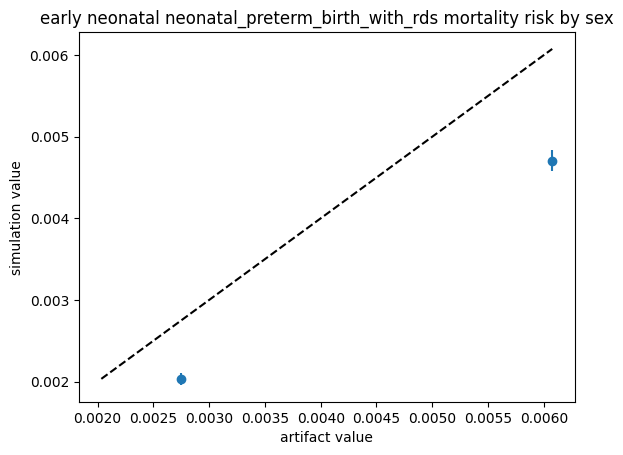

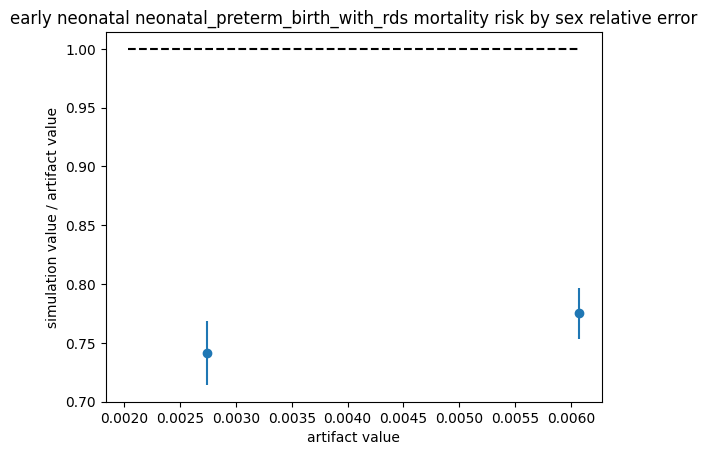

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000480,0.002498,0.0,0.0,0.0,0.0,0.045432
Male,28005.0,0.001115,0.004315,0.0,0.0,0.0,0.0,0.057935


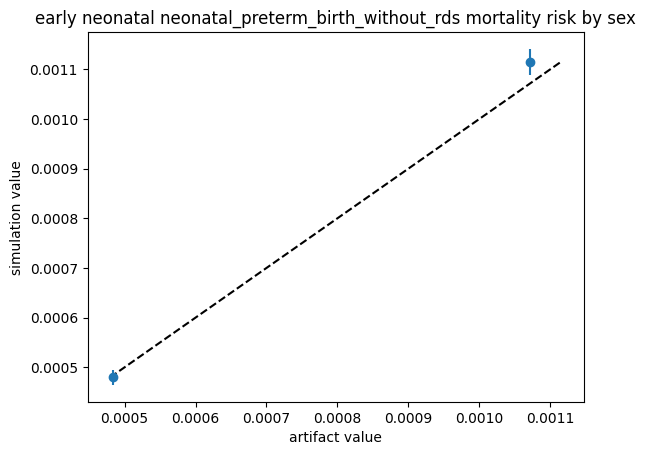

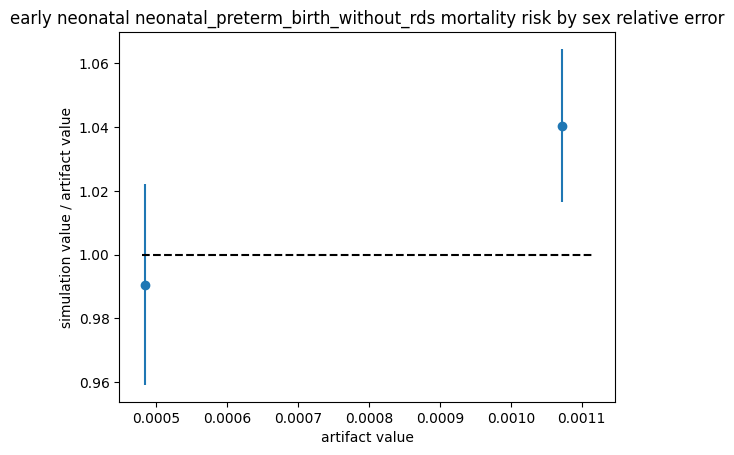

In [42]:
from vivarium_gates_mncnh.constants.data_values import PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY

NEONATAL_CAUSES = [
    'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma',
    'neonatal_sepsis_and_other_neonatal_infections',
    'neonatal_preterm_birth',
    'neonatal_preterm_birth_with_rds',
    'neonatal_preterm_birth_without_rds',
]

CAUSE_NAME_TO_CSMRISK_PIPELINES = {}
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [
            "neonatal_preterm_birth_with_rds.csmr",
            "neonatal_preterm_birth_without_rds.csmr",
        ]
    else:
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [f"{cause_name}.csmr"]

def check_csmrisks(age_group_start, age_group_end):
    for cause_name in NEONATAL_CAUSES:
        print(cause_name)

        pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
        csmrisk_values = 0
        for pipeline_name in pipeline_names:
            csmrisk_values += (
                main_sim.get_population(pipeline_name).loc[alive_idx]
            )

        artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
        csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

        if cause_name == 'neonatal_preterm_birth_with_rds':
            csmrisk_targets *= PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            csmrisk_targets *= (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)

        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_start == LATE_NEONATAL_AGE_START and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(csmrisk_values, csmrisk_targets, f"early neonatal {cause_name} mortality risk", acceptable_deviation=acceptable_deviation)

check_csmrisks(0, LATE_NEONATAL_AGE_START)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [43]:
csmrisk_pipeline_names = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr',
 'neonatal_preterm_birth_with_rds.csmr',
 'neonatal_preterm_birth_without_rds.csmr',
 'neonatal_sepsis_and_other_neonatal_infections.csmr']

In [44]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx]
    )

total_csmrisk

4        0.000921
5        0.051084
6        0.072129
7        0.012961
8        0.010146
           ...   
99993    0.002298
99994    0.001823
99996    0.001731
99997    0.000883
99998    0.002272
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, Length: 54901, dtype: float64

In [45]:
total_csmrisk.describe()

count    54901.000000
mean         0.012890
std          0.044022
min          0.000870
25%          0.001061
50%          0.001844
75%          0.004561
max          0.809029
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, dtype: float64

In [46]:
(total_csmrisk > mortality_risk).mean()

0.0

In [47]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

In [48]:
art.load('cause.neonatal_preterm_birth.population_attributable_fraction')

draw_109  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.958769   
             0.019178        0.076712      2023       2024      0.924062   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   
Male         0.000000        0.019178      2023       2024      0.954761   
             0.019178        0.076712      2023       2024      0.906628   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   

                                                                draw_114  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.957154   
             0.019178        0.076712      2023       2024      0.926533   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   
Male         0.000000        0.019178      2023       2024      0.957099   
             0.019178        0.076712      2023       2024      0.906664   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   

                                                                draw_115  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.960264   
             0.019178        0.076712      2023       2024      0.925287   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   
Male         0.000000        0.019178      2023       2024      0.949693   
             0.019178        0.076712      2023       2024      0.903147   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   

                                                                draw_118  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.961155   
             0.019178        0.076712      2023       2024      0.931245   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   
Male         0.000000        0.019178      2023       2024      0.953805   
             0.019178        0.076712      2023       2024      0.907584   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   

                                                                draw_127  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.956687   
             0.019178        0.076712      2023       2024      0.916176   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   
Male         0.000000        0.019178      2023       2024      0.954679   
             0.019178        0.076712      2023       2024      0.916907   
             0.076712        1.000000      2023       2024      0.000000   
             1.000000        5.000000      2023       2024      0.000000   

                                                                draw_146  \
sex_of_child child_age_start child_age_end year_start year_end             
Female       0.000000        0.019178      2023       2024      0.954454   
             0.019178        0.

In [49]:
art.load('risk_factor.low_birth_weight_and_short_gestation.population_attributable_fraction')[f'draw_{draw_num}']

sex_of_child  child_age_start  child_age_end  year_start  year_end
Female        0.000000         0.019178       2023        2024        0.823820
              0.019178         0.076712       2023        2024        0.763606
              0.076712         1.000000       2023        2024        0.000000
              1.000000         5.000000       2023        2024        0.000000
Male          0.000000         0.019178       2023        2024        0.847768
              0.019178         0.076712       2023        2024        0.776673
              0.076712         1.000000       2023        2024        0.000000
              1.000000         5.000000       2023        2024        0.000000
Name: draw_60, dtype: float64

In [50]:
[k for k in art.keys if 'low_birth_weight' in k]

['risk_factor.low_birth_weight_and_short_gestation.birth_exposure',
 'risk_factor.low_birth_weight_and_short_gestation.exposure',
 'risk_factor.low_birth_weight_and_short_gestation.distribution',
 'risk_factor.low_birth_weight_and_short_gestation.categories',
 'risk_factor.low_birth_weight_and_short_gestation.sex_specific_ordered_categories',
 'risk_factor.low_birth_weight_and_short_gestation.relative_risk',
 'risk_factor.low_birth_weight_and_short_gestation.relative_risk_interpolator',
 'risk_factor.low_birth_weight_and_short_gestation.population_attributable_fraction',
 'intervention.iv_iron.low_birth_weight_and_short_gestation_effect_size']

#### Check individual steps in calculation of cause-specific mortality risks

In [51]:
def step_by_step_check_csmrisk(cause_name, age_group_start, age_group_end):
    artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
    csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial cause-specific mortality risk')
    component_name = ('preterm_birth.' if 'preterm_birth' in cause_name else 'neonatal_cause.') + cause_name
    component = main_sim_components[component_name]
    initial_csmrisk = component.csmrisk_table(alive_idx)
    # Does not vary except by sex
    assert (initial_csmrisk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_csmrisk.groupby(pop.sex_of_child).mean(), csmrisk_targets, rtol=0, atol=1e-14)
    display(initial_csmrisk.groupby(pop.sex_of_child).mean())

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/7886d2bcb71fd2c3e497997a2bcf44c43569b8ab/src/vivarium_gates_mncnh/components/neonatal_causes.py#L116-L136
    global any_failures
    if 'preterm_birth' in cause_name:
        # Next step (conceptually) is limiting to preterm babies
        print('Preterm prevalence:')
        prevalence = component.prevalence_table(alive_idx)
        # Does not vary except by sex
        assert (prevalence.groupby(pop.sex_of_child).nunique() == 1).all()
        display(prevalence.groupby(pop.sex_of_child).mean())

        ga_greater_than_37 = main_sim.get_population("gestational_age.exposure").loc[alive_idx] >= 37.0
        for sex in ['Female', 'Male']:
            try:
                fuzzy_checker.fuzzy_assert_proportion(
                    (~ga_greater_than_37)[pop.loc[alive_idx].sex_of_child == sex].sum(),
                    (pop.loc[alive_idx].sex_of_child == sex).sum(),
                    prevalence[pop.sex_of_child == sex].mean()
                )
            except AssertionError as e:
                print(e)
                any_failures = True
    
        limited_csmrisk_preterm = initial_csmrisk / prevalence
        limited_csmrisk_preterm.loc[ga_greater_than_37] = 0
        display(limited_csmrisk_preterm.groupby(pop.sex_of_child).mean())

        fuzzy_check(limited_csmrisk_preterm, csmrisk_targets, "CSMRisk after limiting to preterm")

        working_csmrisk = limited_csmrisk_preterm

        if cause_name == 'neonatal_preterm_birth_with_rds':
            working_csmrisk = working_csmrisk * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
            csmrisk_targets = csmrisk_targets * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            working_csmrisk = working_csmrisk * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
            csmrisk_targets = csmrisk_targets * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
        
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after splitting to subcause")
    else:
        working_csmrisk = initial_csmrisk

    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    # Next (conceptually) is applying LBWSG PAF/normalizing constant and RR
    # TODO: Why is this different! Note that there is a PAF table on the risk effect, but it is not actually used!
    if 'preterm_birth' in cause_name:
        lbwsg_paf = component.paf_table(alive_idx)
    else:
        lbwsg_paf = main_sim_components[f'risk_effect.low_birth_weight_and_short_gestation_on_cause.{cause_name}.cause_specific_mortality_risk'].paf_table(alive_idx)
    lbwsg_rr = main_sim.get_population(f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_{cause_name}_relative_risk').loc[alive_idx]

    csmrisk_after_lbwsg = working_csmrisk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(csmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(csmrisk_after_lbwsg, csmrisk_targets, "CSMRisk after LBWSG")

    pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
    assert len(pipeline_names) == 1
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()[pipeline_names[0]]

    # Check that we've exactly replicated everything up to mutators
    assert np.allclose(csmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in intervention-based modifications
    print('Mutators:')
    display(pipeline.mutators)

    working_csmrisk = csmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator}')
        working_csmrisk = mutator(alive_idx, working_csmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_name == 'late_neonatal' and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_csmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.004124
Male      0.009226
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.004285,0.013360,0.000726,0.000726,0.000875,0.001741,0.222860
Male,28005.0,0.009655,0.024945,0.001404,0.001412,0.001913,0.004680,0.298588


Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.004285,0.013360,0.000726,0.000726,0.000875,0.001741,0.222860
Male,28005.0,0.009655,0.024945,0.001404,0.001412,0.001913,0.004680,0.298588


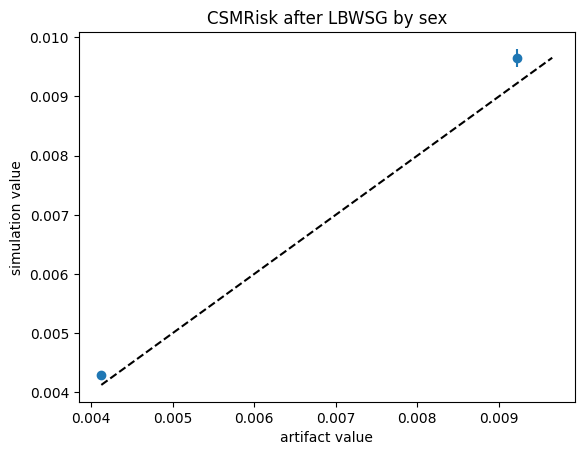

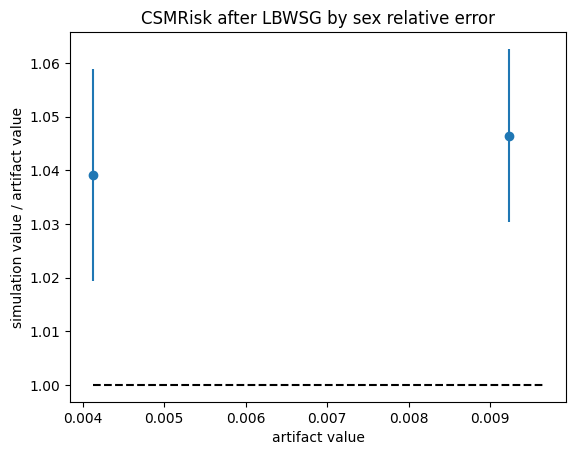

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000861
Male      0.002649
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000895,0.002790,0.000152,0.000152,0.000183,0.000364,0.046546
Male,28005.0,0.002772,0.007161,0.000403,0.000405,0.000549,0.001344,0.085717


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000895,0.002790,0.000152,0.000152,0.000183,0.000364,0.046546
Male,28005.0,0.002772,0.007161,0.000403,0.000405,0.000549,0.001344,0.085717


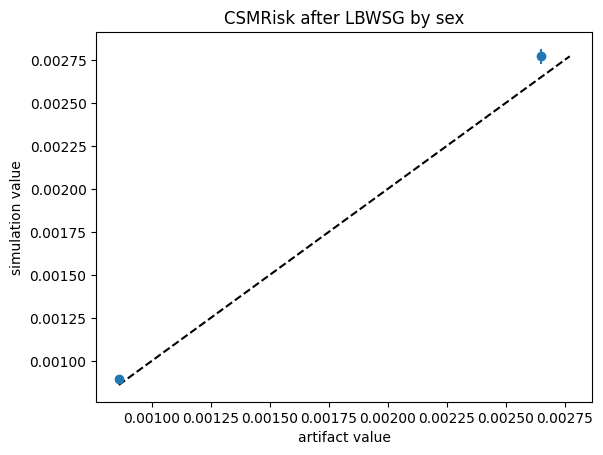

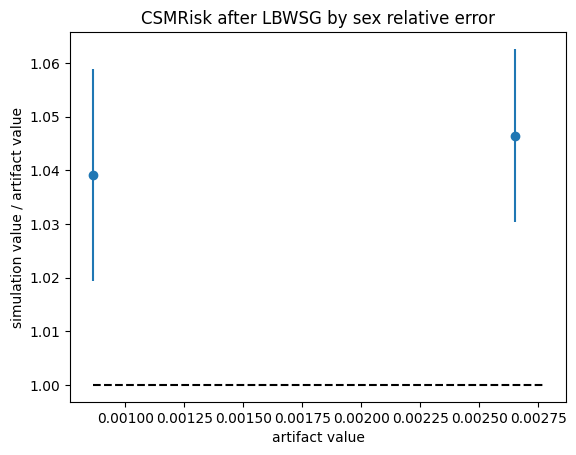

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af9163f10>
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000848,0.002644,0.000144,0.000144,0.000173,0.000345,0.044107
Male,28005.0,0.002627,0.006786,0.000382,0.000384,0.000521,0.001273,0.081226


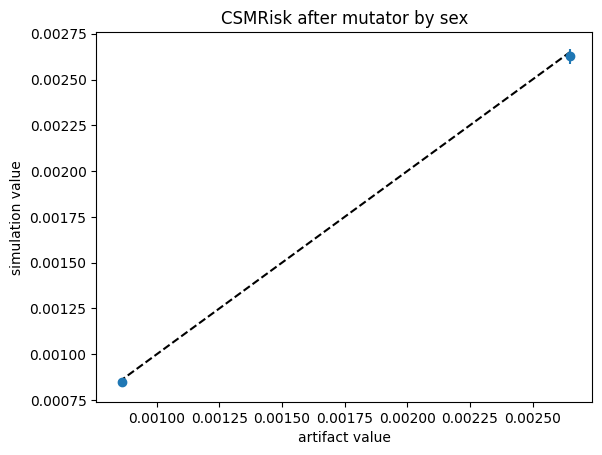

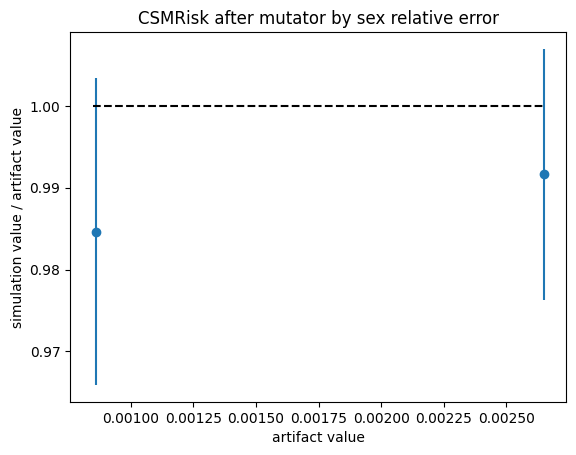

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af92361d0>
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000807,0.002478,0.000144,0.000144,0.000173,0.000338,0.044107
Male,28005.0,0.002487,0.006433,0.000382,0.000384,0.000518,0.001241,0.081226


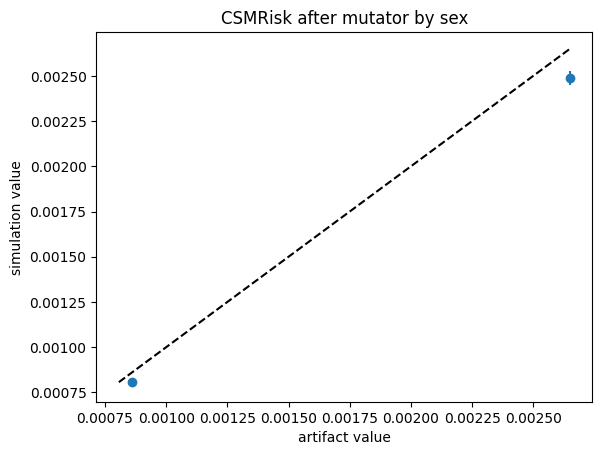

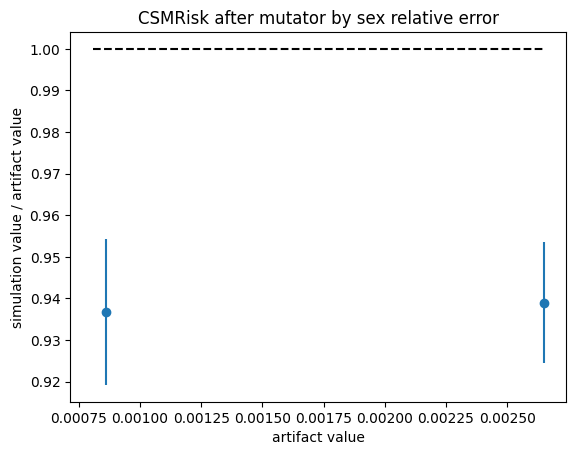

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

2026-05-14 15:16:26.683 | WARNING  | vivarium_testing_utils.fuzzy_checker:235 - Bayes factor for '' is not conclusive.


sex_of_child
Female    0.003315
Male      0.007443
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.003315,0.008098,0.0,0.0,0.0,0.0,0.023095
Male,28005.0,0.007443,0.014941,0.0,0.0,0.0,0.0,0.037435


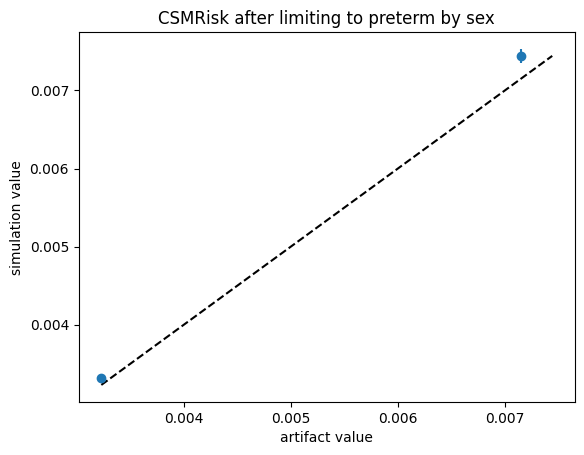

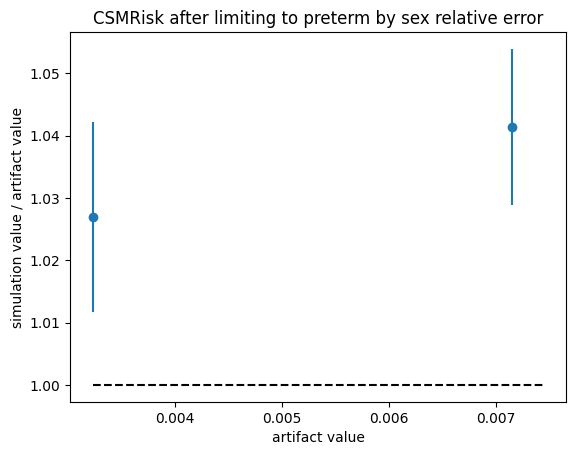

Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002818,0.006883,0.0,0.0,0.0,0.0,0.019631
Male,28005.0,0.006326,0.012700,0.0,0.0,0.0,0.0,0.031820


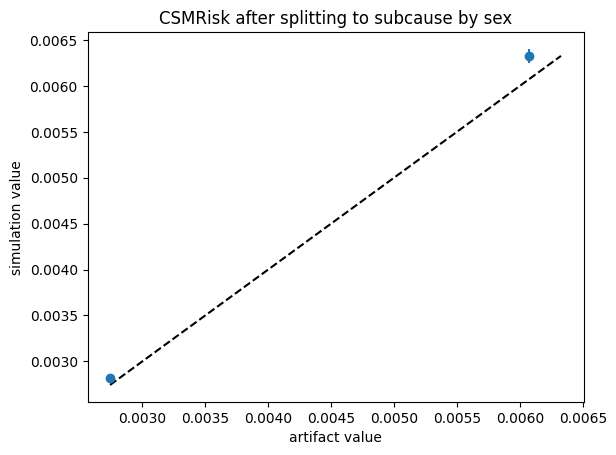

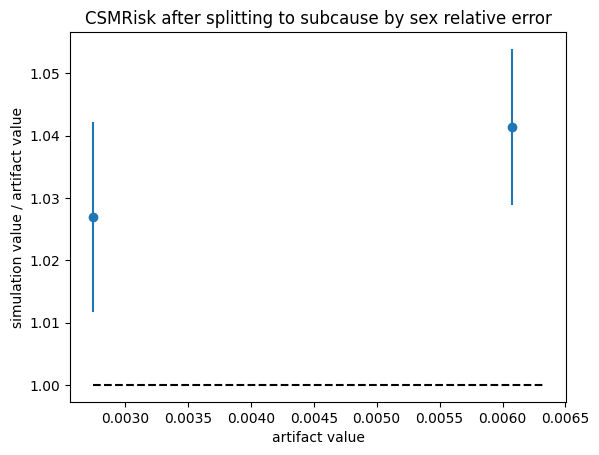

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002718,0.014154,0.0,0.0,0.0,0.0,0.257450
Male,28005.0,0.006321,0.024454,0.0,0.0,0.0,0.0,0.328299


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002718,0.014154,0.0,0.0,0.0,0.0,0.257450
Male,28005.0,0.006321,0.024454,0.0,0.0,0.0,0.0,0.328299


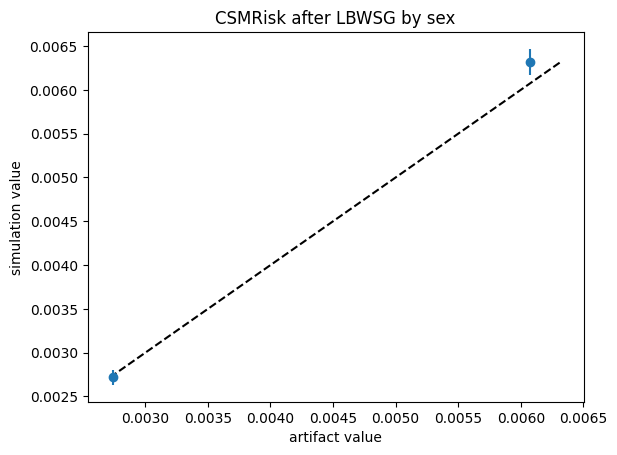

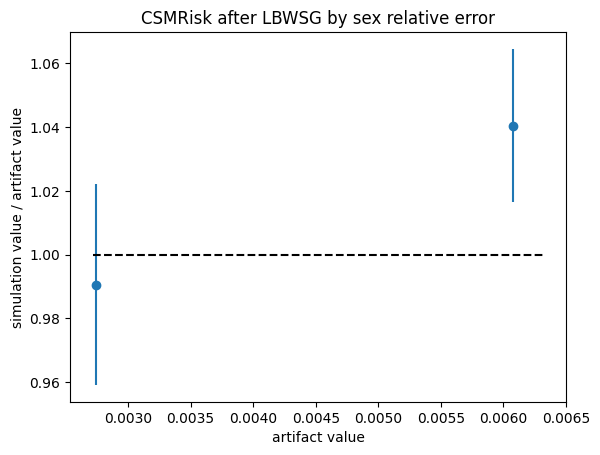

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af8a25950>
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.002034,0.012183,0.0,0.0,0.0,0.0,0.287345
Male,28005.0,0.004708,0.021788,0.0,0.0,0.0,0.0,0.371280


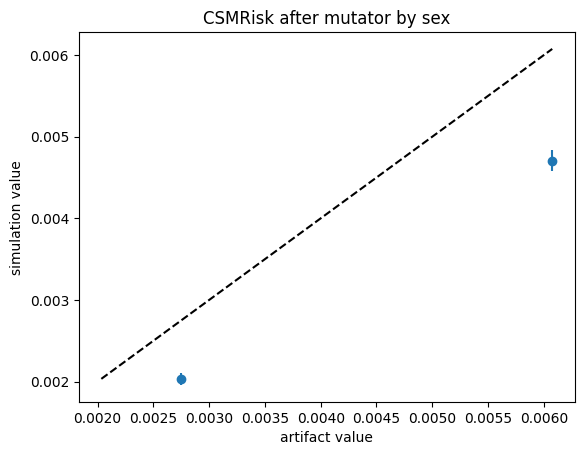

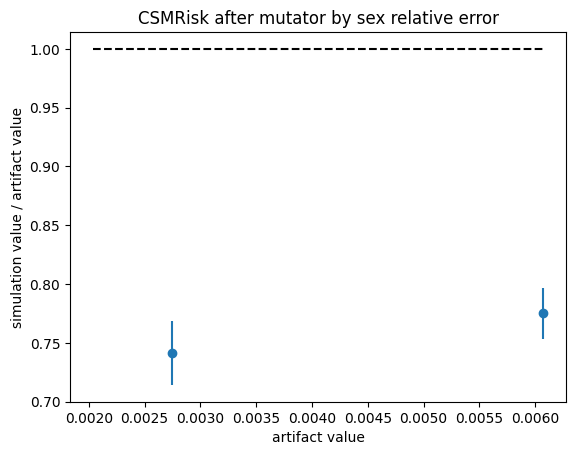

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

2026-05-14 15:16:28.501 | WARNING  | vivarium_testing_utils.fuzzy_checker:235 - Bayes factor for '' is not conclusive.


sex_of_child
Female    0.003315
Male      0.007443
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.003315,0.008098,0.0,0.0,0.0,0.0,0.023095
Male,28005.0,0.007443,0.014941,0.0,0.0,0.0,0.0,0.037435


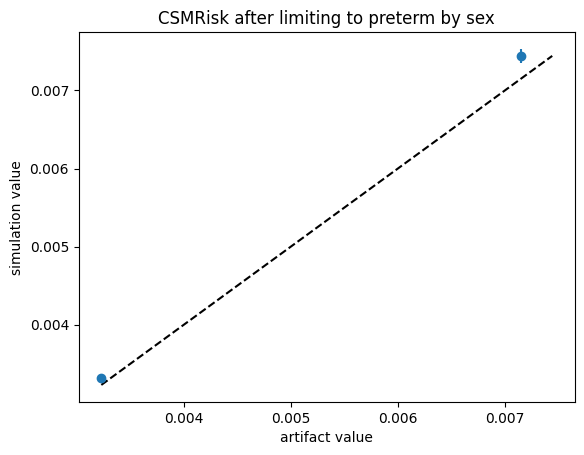

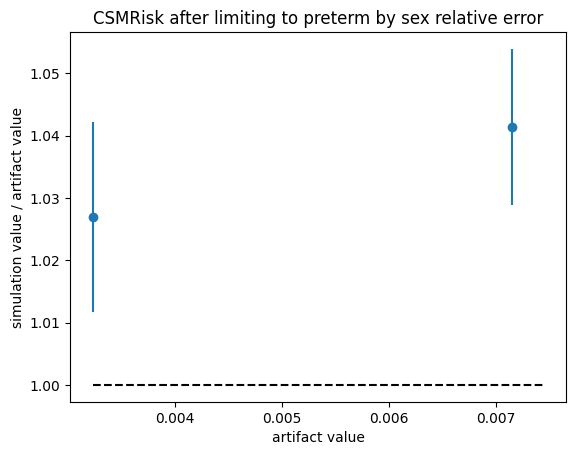

Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000497,0.001215,0.0,0.0,0.0,0.0,0.003464
Male,28005.0,0.001116,0.002241,0.0,0.0,0.0,0.0,0.005615


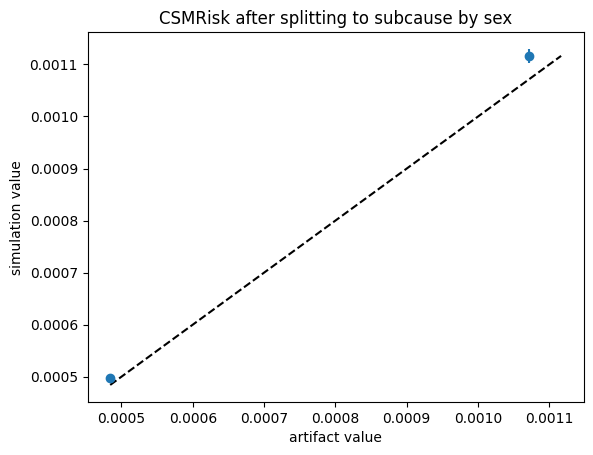

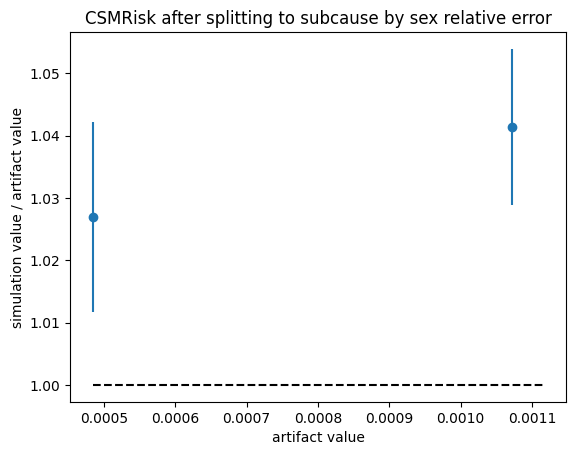

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000480,0.002498,0.0,0.0,0.0,0.0,0.045432
Male,28005.0,0.001115,0.004315,0.0,0.0,0.0,0.0,0.057935


Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26896.0,0.000480,0.002498,0.0,0.0,0.0,0.0,0.045432
Male,28005.0,0.001115,0.004315,0.0,0.0,0.0,0.0,0.057935


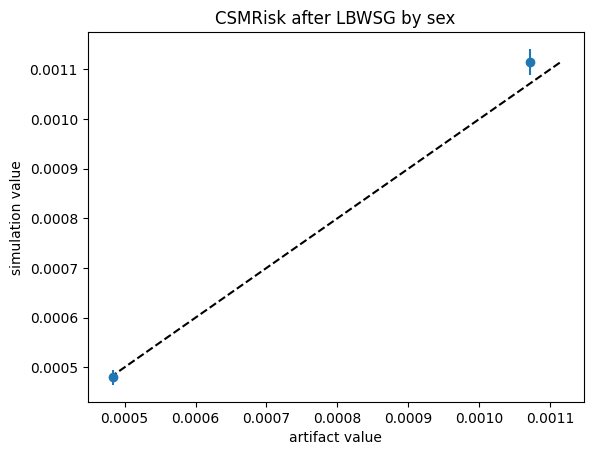

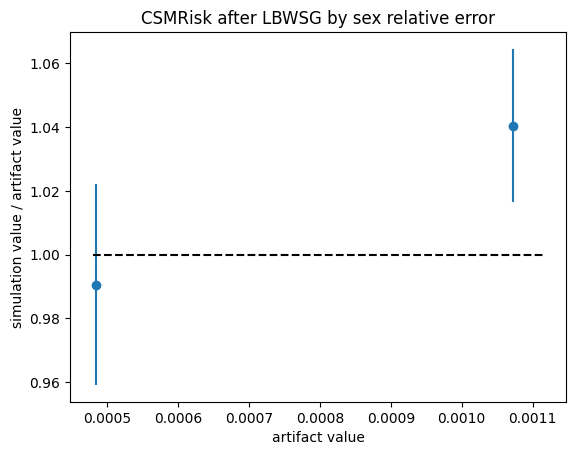

Mutators:


[]

In [52]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, 0, LATE_NEONATAL_AGE_START)

## LNN mortality

### Step main sim to LNN mortality

In [53]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'early_neonatal_mortality'

In [54]:
%%time

while get_event_name() != 'late_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-05-14 15:16:29.490 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-19 00:00:00
late_neonatal_mortality
CPU times: user 15.7 s, sys: 189 ms, total: 15.9 s
Wall time: 15.8 s


In [55]:
assert get_event_name() == 'late_neonatal_mortality'

In [56]:
# We now step to the *middle* of a time step
# https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/engine.py#L260-L268
self = main_sim
for event in self.time_step_events:
    self._lifecycle.set_state(event)
    pop_to_update = self._clock.get_active_simulants(
        self.get_population_index(),
        self._clock.event_time,
    )
    # https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/event.py#L119-L141
    clock = self._events.clock()
    step_size = self._events.step_size()
    event_time = clock + step_size

    e = Event(
        "time_step",
        pop_to_update,
        {},
        event_time,
        step_size,
    )

    listener = None
    listeners = self.time_step_emitters[event].__self__.listeners
    for priority_bucket in listeners:
        for listener in priority_bucket:
            if listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
                break
            listener(e)
        if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

    if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

In [57]:
assert listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step"

In [58]:
pop = main_sim.get_population([
    "child_alive",
    "child_age",
])
assert (pop[pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (pop[pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

In [59]:
alive_idx = pop.index[pop['child_alive'] == True]

### Feed ENN PAFs back into the PAF sim

In [60]:
acmr_paf_components = [k for k in paf_sim_components if 'risk_effect.low_birth_weight_' in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk']

In [61]:
for component in acmr_paf_components:
    update_lookup_table(paf_sim_components[component].paf_table, acmrisk_pafs)

In [62]:
# Check that our transfer actually worked
assert (
    set(paf_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[alive_idx])
    <=
    set(acmrisk_pafs['value'].unique())
)

### Step PAF sim to LNN

In [63]:
%%time

assert (paf_sim.get_population("child_age") < LATE_NEONATAL_AGE_START).all()
paf_sim.step()

2026-05-14 15:16:46.362 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2022-01-01 00:00:00
CPU times: user 768 ms, sys: 12.3 ms, total: 780 ms
Wall time: 773 ms


In [64]:
paf_sim_pop = paf_sim.get_population([
    "child_alive",
    "child_age",
])
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

### Transfer PAFs and preterm prevalence to main sim

In [65]:
paf_observer = paf_sim_components['lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk']

In [66]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [67]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823836,0.000000,0.019178,2021,2022
1,Male,0.847793,0.000000,0.019178,2021,2022
2,Female,0.763177,0.019178,0.076712,2021,2022
3,Male,0.776130,0.019178,0.076712,2021,2022


In [68]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957251,0.000000,0.019178,2021,2022
1,Male,0.951475,0.000000,0.019178,2021,2022
2,Female,0.929211,0.019178,0.076712,2021,2022
3,Male,0.913177,0.019178,0.076712,2021,2022


In [69]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [70]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs)

In [71]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [72]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs)

In [73]:
late_neonatal_preterm_prevalence = paf_sim.get_results()['calculated_late_neonatal_preterm_prevalence'].assign(
    child_age_start=LATE_NEONATAL_AGE_START,
    child_age_end=LATE_NEONATAL_AGE_END,
    year_start=2023,
    year_end=2024,
).rename(columns={"child_sex": "sex_of_child"})
late_neonatal_preterm_prevalence

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.133268,0.019178,0.076712,2023,2024
1,Male,0.179810,0.019178,0.076712,2023,2024


In [74]:
preterm_prevalence_components = [k for k in main_sim_components if 'preterm_birth.' in k]

for component in preterm_prevalence_components:
    lookup_table = main_sim_components[component].prevalence_table
    enn_data = lookup_table.data[lookup_table.data.child_age_start == 0]
    update_lookup_table(lookup_table, pd.concat([enn_data, late_neonatal_preterm_prevalence], ignore_index=True))

In [75]:
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].prevalence_table(alive_idx).unique())
    <=
    set(late_neonatal_preterm_prevalence['value'].unique())
)

### Check all-cause mortality risk

In [76]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [77]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [78]:
acmrisk_targets = get_acmrisk_targets(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)
acmrisk_targets

sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004375,0.013028,0.001012,0.001229,0.001769,0.003279,0.425509
Male,27266.0,0.007360,0.019718,0.001620,0.002225,0.003297,0.006071,0.671073


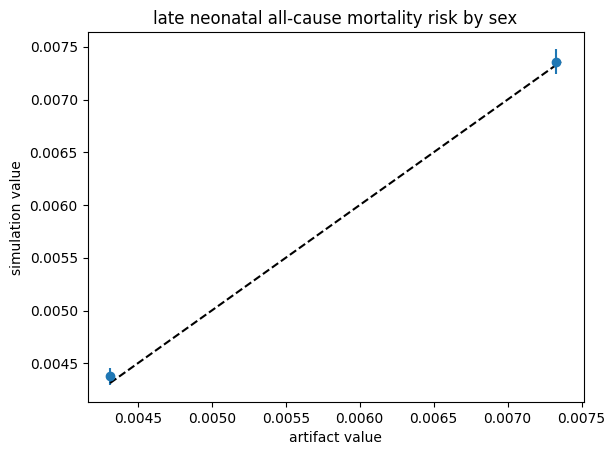

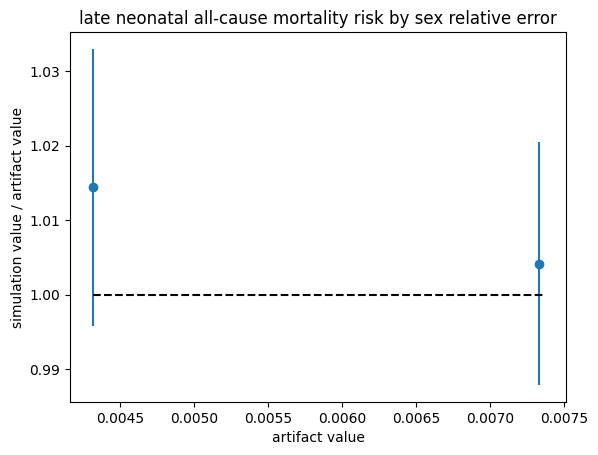

In [79]:
fuzzy_check(mortality_risk, acmrisk_targets, "late neonatal all-cause mortality risk", acceptable_deviation=0.01)

#### Check individual steps in calculation of all-cause mortality risk

Initial mortality risk


sex_of_child
Female    0.004313
Male      0.007330
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004566,0.014122,0.001021,0.001240,0.001789,0.003372,0.459408
Male,27266.0,0.007845,0.021550,0.001641,0.002258,0.003380,0.006381,0.659294


Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004566,0.014122,0.001021,0.001240,0.001789,0.003372,0.459408
Male,27266.0,0.007845,0.021550,0.001641,0.002258,0.003380,0.006381,0.659294


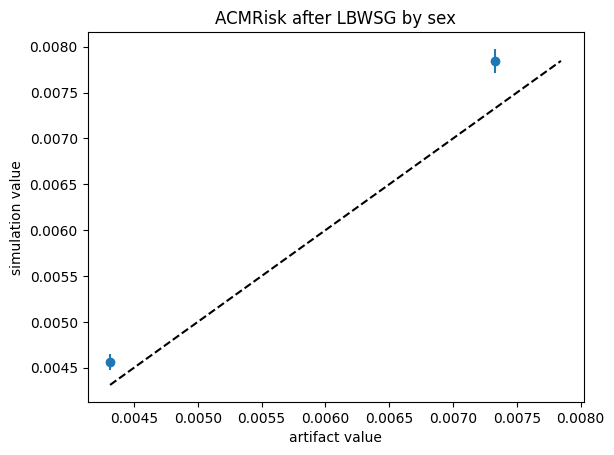

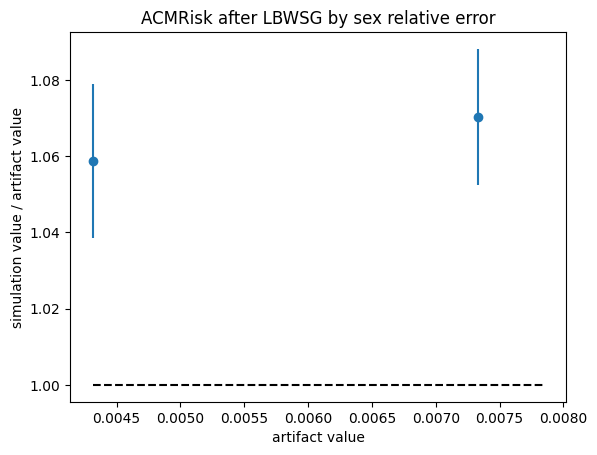

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af910a610>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004445,0.013333,0.001021,0.001240,0.001786,0.003321,0.429151
Male,27266.0,0.007542,0.020316,0.001641,0.002256,0.003349,0.006209,0.679469


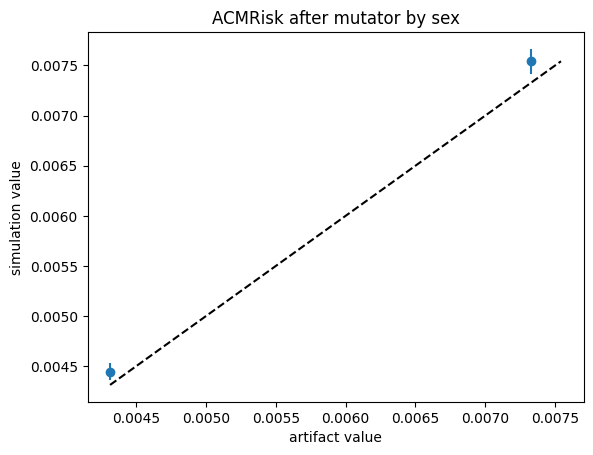

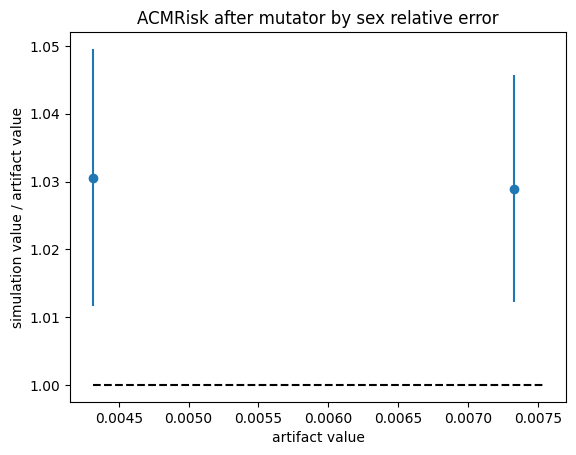

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af89f7f10>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004445,0.013333,0.001021,0.001240,0.001786,0.003321,0.429151
Male,27266.0,0.007542,0.020316,0.001641,0.002256,0.003349,0.006209,0.679469


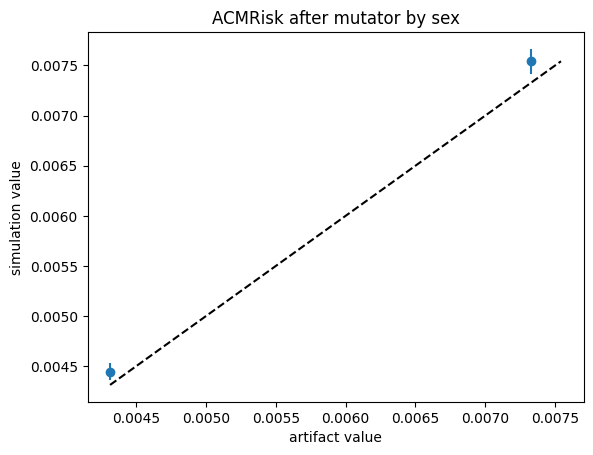

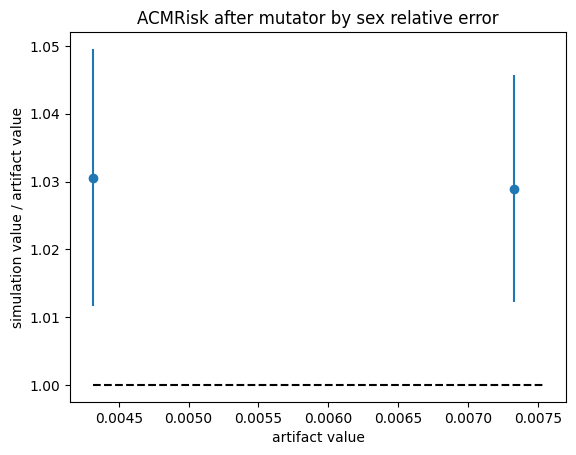

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af89ef950>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004375,0.013028,0.001012,0.001229,0.001769,0.003279,0.425509
Male,27266.0,0.007360,0.019718,0.001620,0.002225,0.003297,0.006071,0.671073


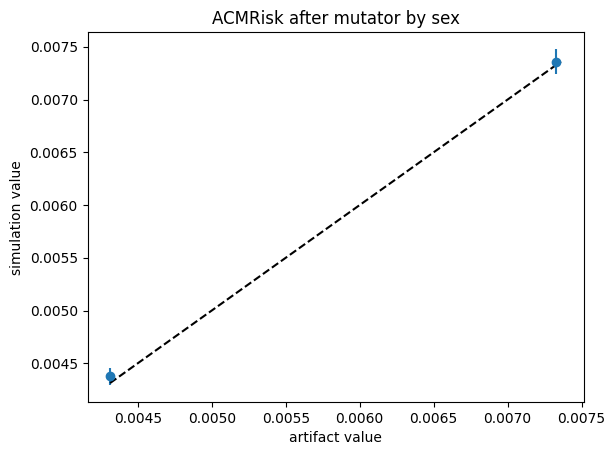

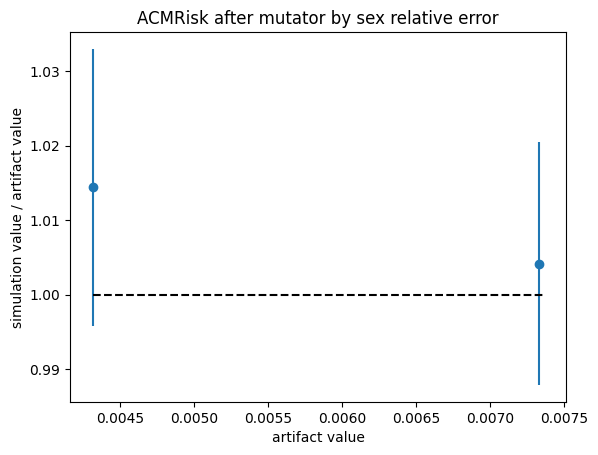

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af8a48810>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.004375,0.013028,0.001012,0.001229,0.001769,0.003279,0.425509
Male,27266.0,0.007360,0.019718,0.001620,0.002225,0.003297,0.006071,0.671073


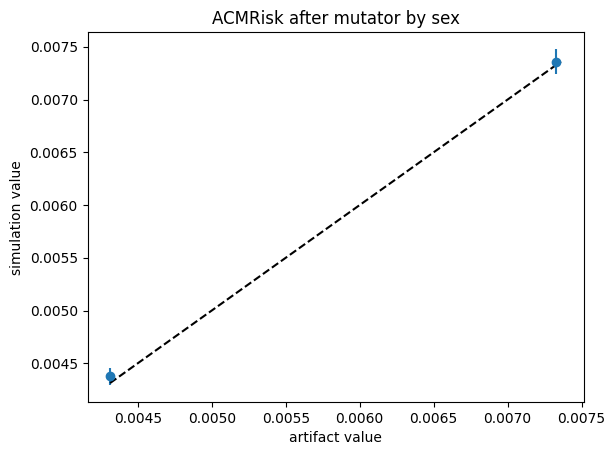

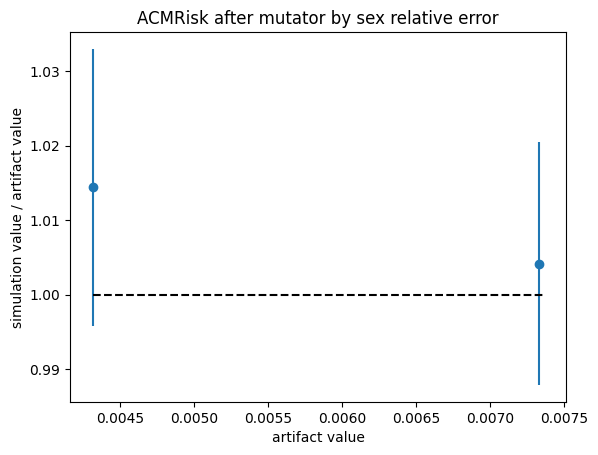

In [80]:
step_by_step_check_acmrisk(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

### Check cause-specific mortality risks

In [81]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[alive_idx].unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [82]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lbwsg_acmr_paf(main_sim.get_population_index()).unique())
    <=
    set(preterm_csmr_pafs['value'].unique())
)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000392,0.001213,0.000088,0.000106,0.000154,0.00029,0.039461
Male,27266.0,0.001094,0.003005,0.000229,0.000315,0.000471,0.00089,0.091927


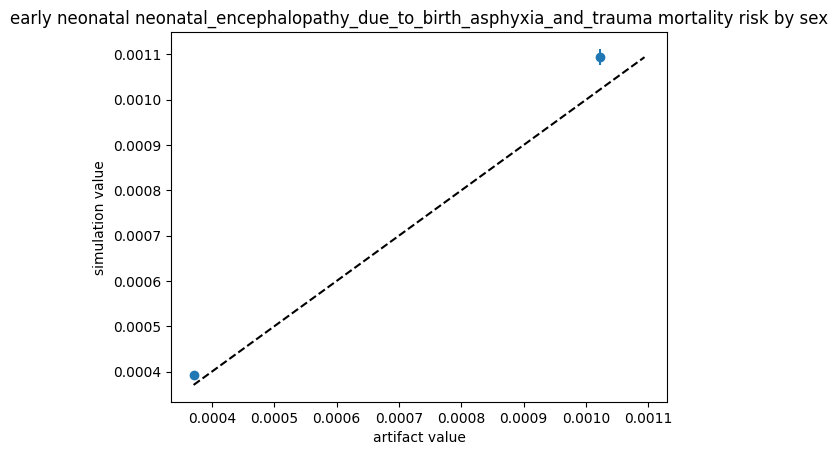

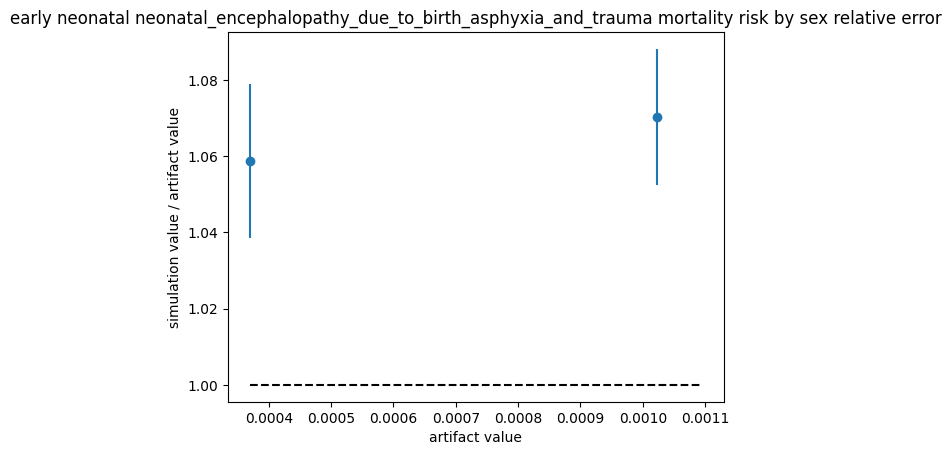

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000689,0.002031,0.000161,0.000195,0.000281,0.000517,0.065861
Male,27266.0,0.001732,0.004617,0.000379,0.000521,0.000773,0.001428,0.151834


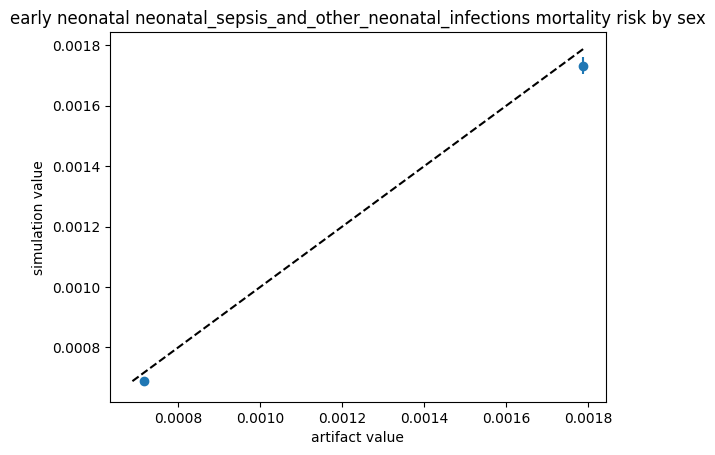

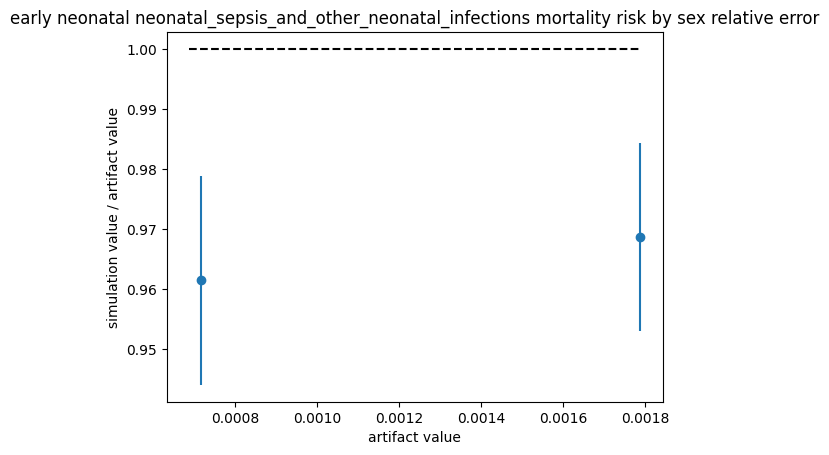

neonatal_preterm_birth
Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000387,0.002730,0.0,0.0,0.0,0.0,0.117681
Male,27266.0,0.000990,0.006107,0.0,0.0,0.0,0.0,0.250120


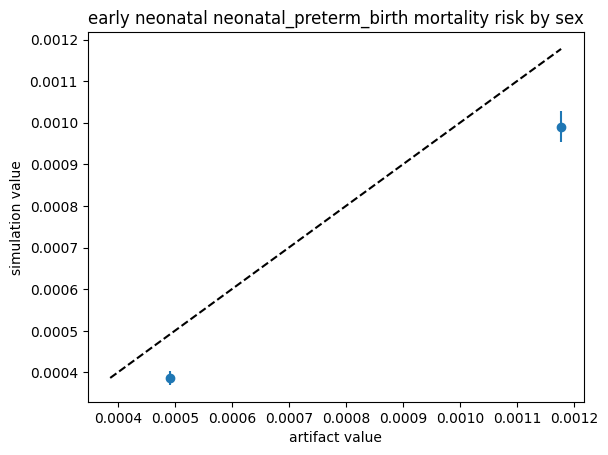

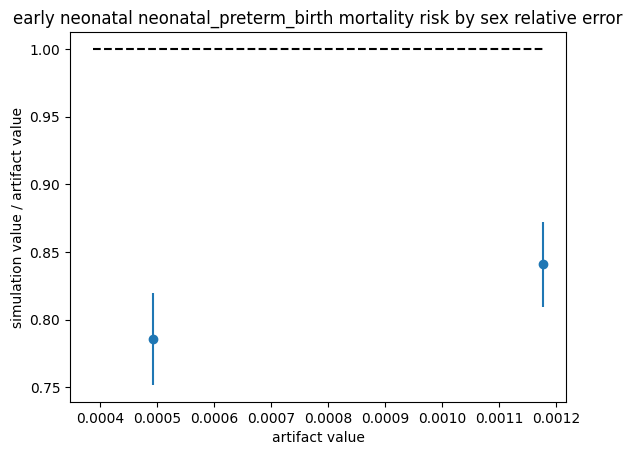

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000310,0.002265,0.0,0.0,0.0,0.0,0.101615
Male,27266.0,0.000796,0.005123,0.0,0.0,0.0,0.0,0.215973


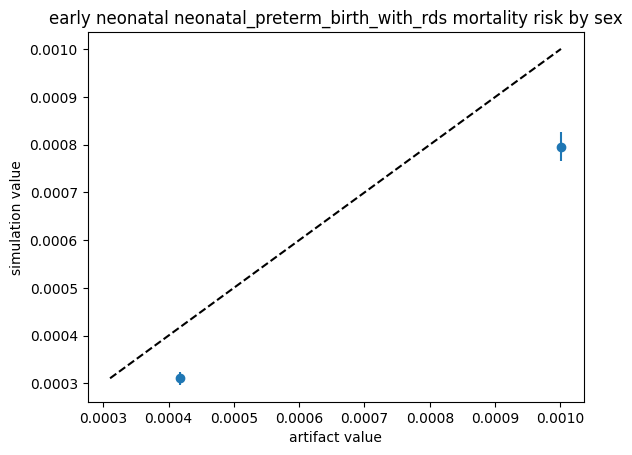

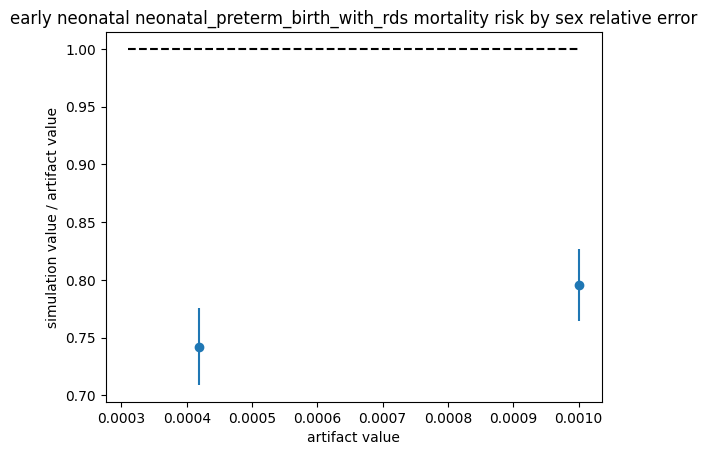

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000076,0.000514,0.0,0.0,0.0,0.0,0.017634
Male,27266.0,0.000194,0.001074,0.0,0.0,0.0,0.0,0.034267


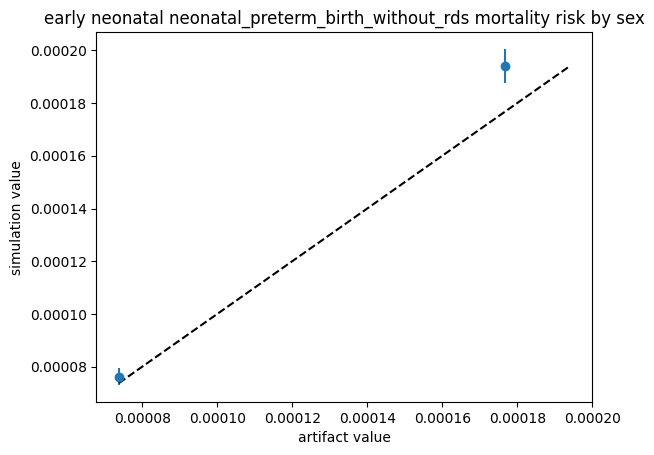

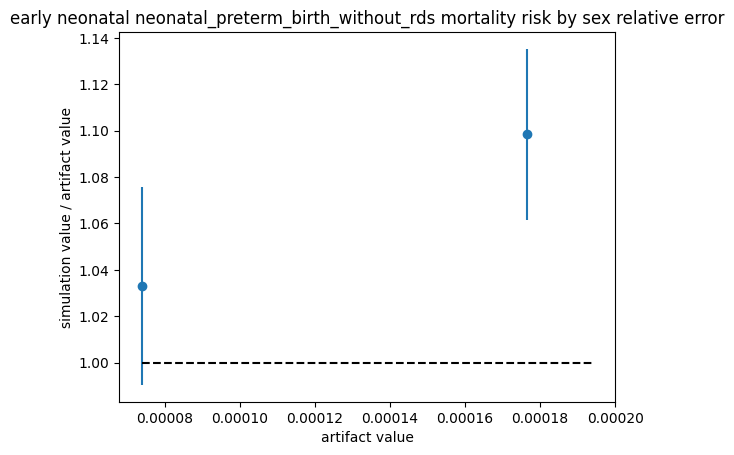

In [83]:
check_csmrisks(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [84]:
csmrisk_pipeline_names = result = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr',
 'neonatal_preterm_birth_with_rds.csmr',
 'neonatal_preterm_birth_without_rds.csmr',
 'neonatal_sepsis_and_other_neonatal_infections.csmr']

In [85]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx].rename('total_csmrisk')
    )

total_csmrisk

4        0.000350
5        0.008004
6        0.014666
8        0.003639
9        0.016226
           ...   
99993    0.000993
99994    0.000833
99996    0.000788
99997    0.000366
99998    0.001315
Name: total_csmrisk, Length: 53752, dtype: float64

In [86]:
total_csmrisk.describe()

count    53752.000000
mean         0.002659
std          0.010351
min          0.000248
25%          0.000441
50%          0.000859
75%          0.001856
max          0.493561
Name: total_csmrisk, dtype: float64

In [87]:
(total_csmrisk > mortality_risk).mean()

0.0

In [88]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.000370
Male      0.001022
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000392,0.001213,0.000088,0.000106,0.000154,0.00029,0.039461
Male,27266.0,0.001094,0.003005,0.000229,0.000315,0.000471,0.00089,0.091927


Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000392,0.001213,0.000088,0.000106,0.000154,0.00029,0.039461
Male,27266.0,0.001094,0.003005,0.000229,0.000315,0.000471,0.00089,0.091927


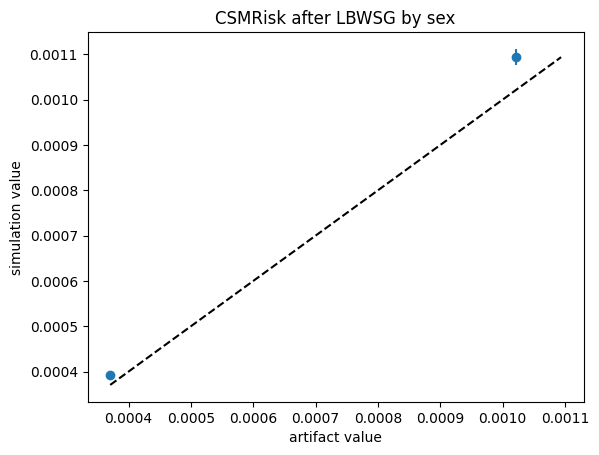

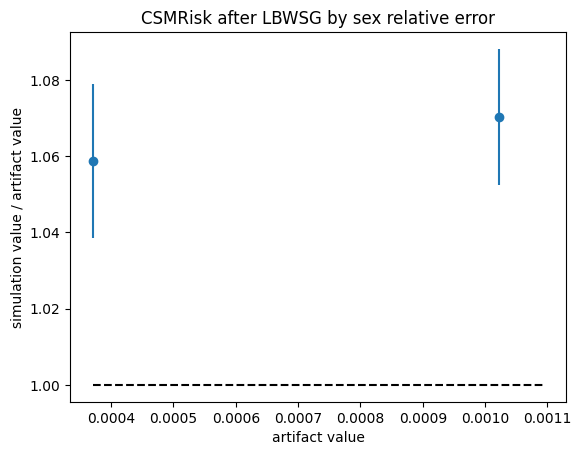

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000716
Male      0.001788
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000758,0.002345,0.00017,0.000206,0.000297,0.000560,0.076283
Male,27266.0,0.001913,0.005256,0.00040,0.000551,0.000824,0.001556,0.160789


Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000758,0.002345,0.00017,0.000206,0.000297,0.000560,0.076283
Male,27266.0,0.001913,0.005256,0.00040,0.000551,0.000824,0.001556,0.160789


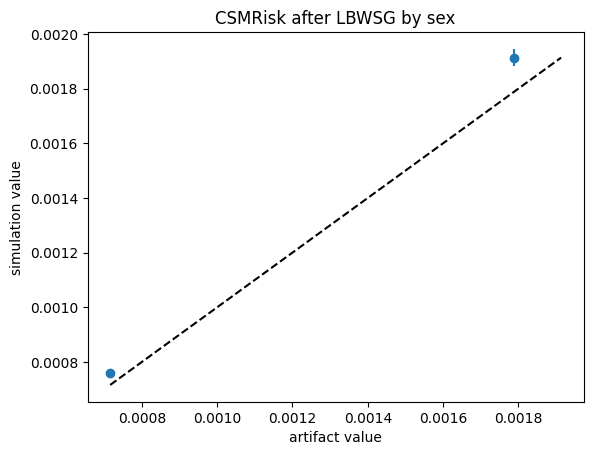

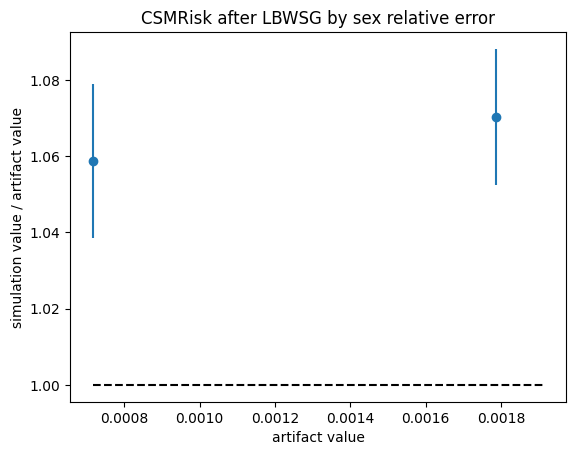

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af9163f10>
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000718,0.002222,0.000161,0.000195,0.000281,0.000531,0.072286
Male,27266.0,0.001813,0.004980,0.000379,0.000522,0.000781,0.001475,0.152364


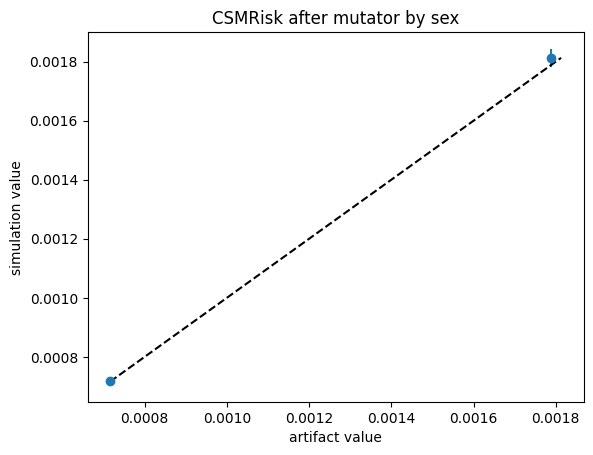

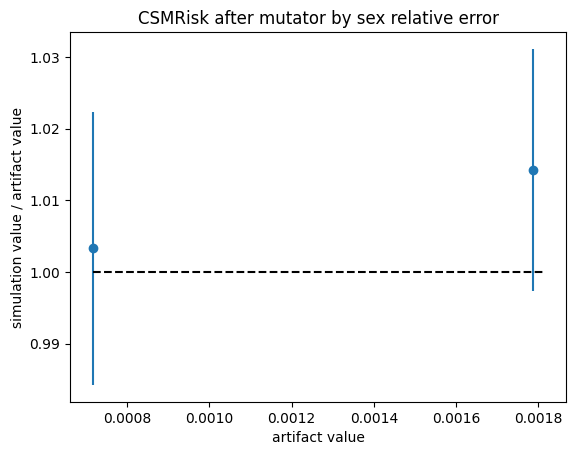

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af92361d0>
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000689,0.002031,0.000161,0.000195,0.000281,0.000517,0.065861
Male,27266.0,0.001732,0.004617,0.000379,0.000521,0.000773,0.001428,0.151834


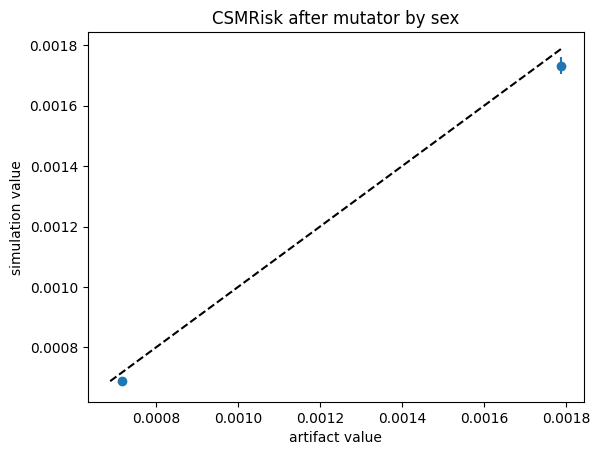

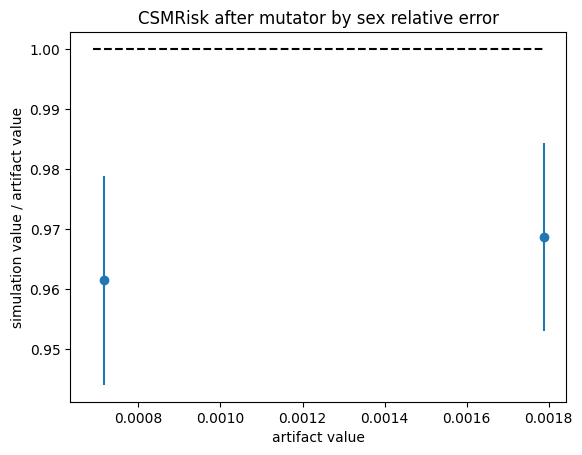

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133268
Male      0.179810
Name: value, dtype: float64

2026-05-14 15:16:57.821 | WARNING  | vivarium_testing_utils.fuzzy_checker:235 - Bayes factor for '' is not conclusive.


sex_of_child
Female    0.000508
Male      0.001233
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000508,0.001272,0.0,0.0,0.0,0.0,0.003692
Male,27266.0,0.001233,0.002560,0.0,0.0,0.0,0.0,0.006549


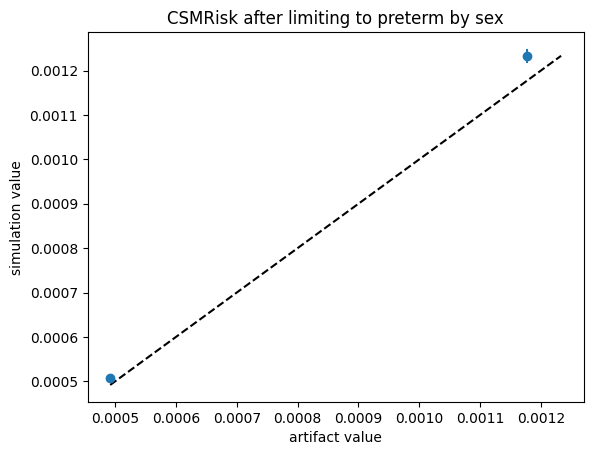

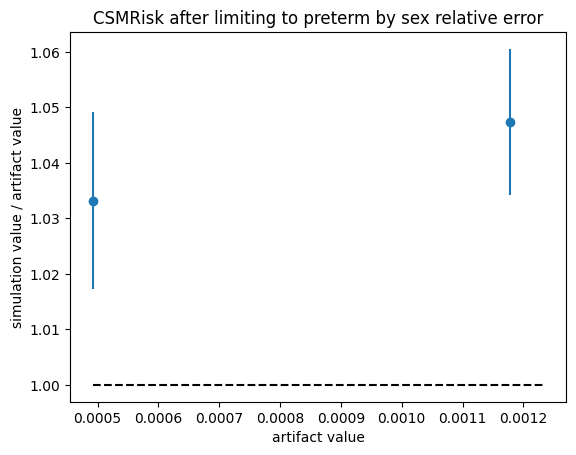

Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000432,0.001081,0.0,0.0,0.0,0.0,0.003138
Male,27266.0,0.001048,0.002176,0.0,0.0,0.0,0.0,0.005566


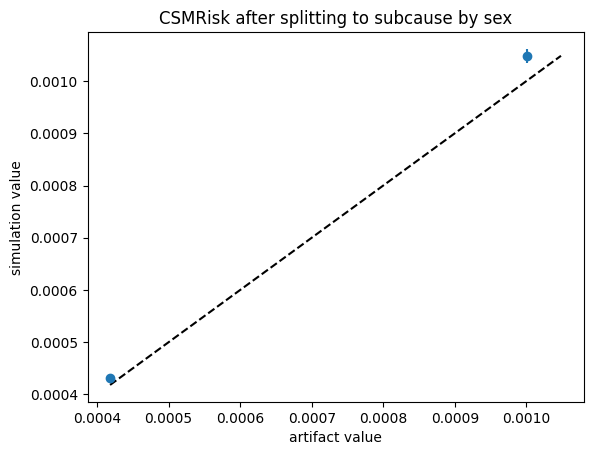

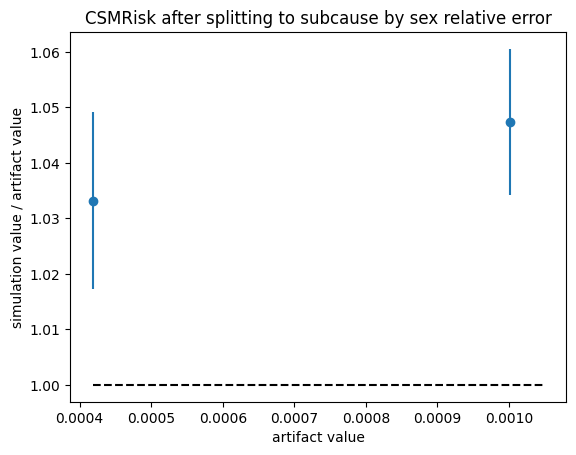

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000432,0.002910,0.0,0.0,0.0,0.0,0.099924
Male,27266.0,0.001099,0.006088,0.0,0.0,0.0,0.0,0.194179


Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000432,0.002910,0.0,0.0,0.0,0.0,0.099924
Male,27266.0,0.001099,0.006088,0.0,0.0,0.0,0.0,0.194179


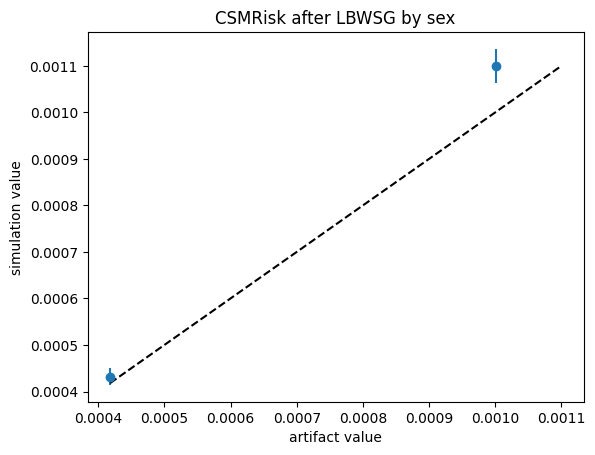

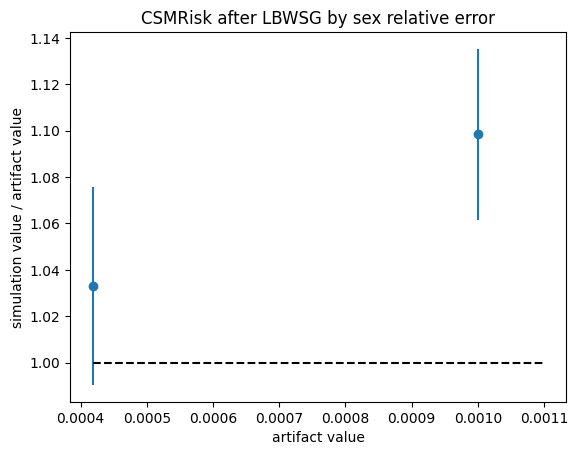

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f1af8a25950>
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000310,0.002265,0.0,0.0,0.0,0.0,0.101615
Male,27266.0,0.000796,0.005123,0.0,0.0,0.0,0.0,0.215973


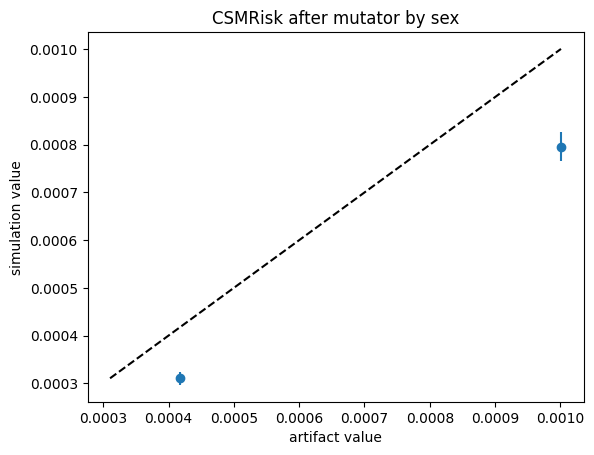

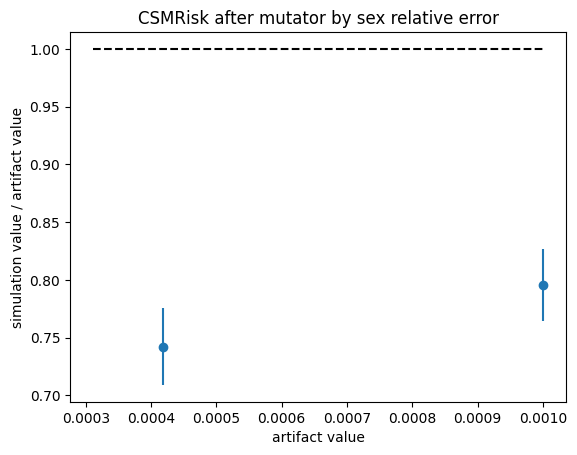

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133268
Male      0.179810
Name: value, dtype: float64

2026-05-14 15:16:59.763 | WARNING  | vivarium_testing_utils.fuzzy_checker:235 - Bayes factor for '' is not conclusive.


sex_of_child
Female    0.000508
Male      0.001233
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000508,0.001272,0.0,0.0,0.0,0.0,0.003692
Male,27266.0,0.001233,0.002560,0.0,0.0,0.0,0.0,0.006549


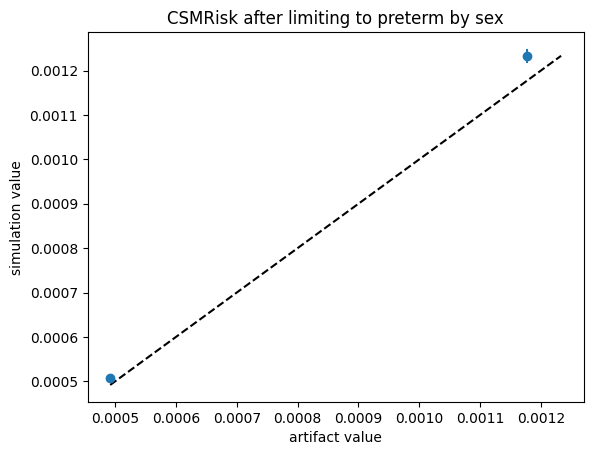

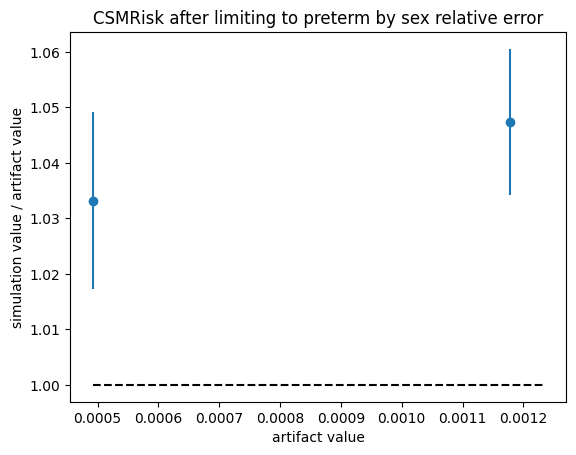

Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000076,0.000191,0.0,0.0,0.0,0.0,0.000554
Male,27266.0,0.000185,0.000384,0.0,0.0,0.0,0.0,0.000982


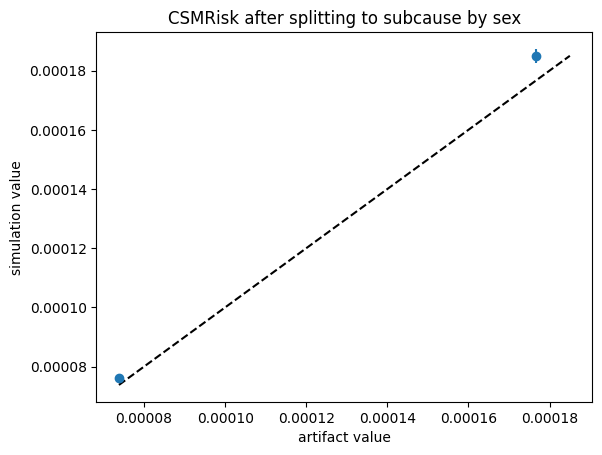

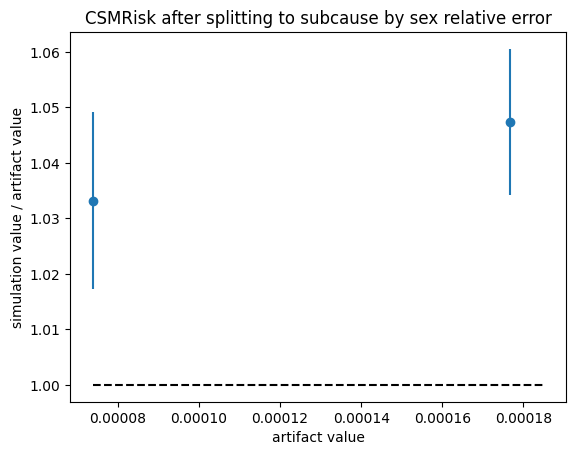

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000076,0.000514,0.0,0.0,0.0,0.0,0.017634
Male,27266.0,0.000194,0.001074,0.0,0.0,0.0,0.0,0.034267


Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,26486.0,0.000076,0.000514,0.0,0.0,0.0,0.0,0.017634
Male,27266.0,0.000194,0.001074,0.0,0.0,0.0,0.0,0.034267


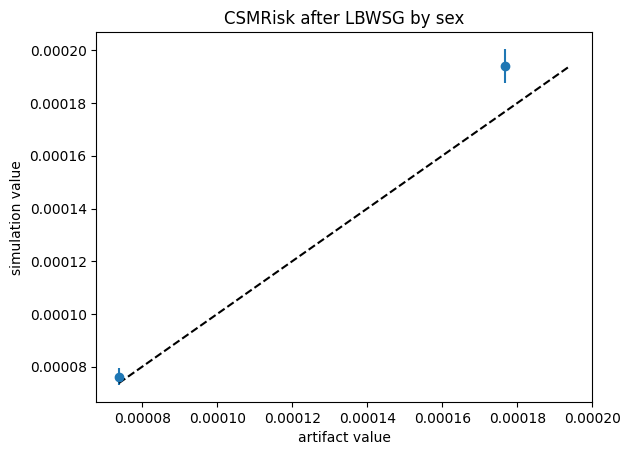

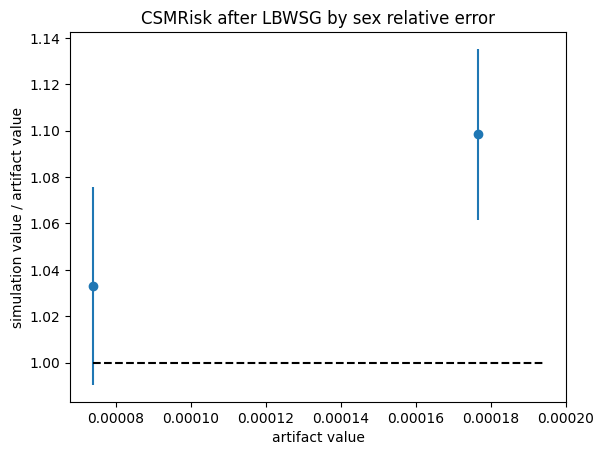

Mutators:


[]

In [89]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

In [90]:
assert not any_failures

In [91]:
!date

Thu May 14 15:17:00 PDT 2026
